In [1]:
# =============================================================================
# BASINS OF ATTRACTION IN THE DIVIDE THE CAKE GAME
# =============================================================================
# Multi-Agent Reinforcement Learning and Equilibrium Selection
#
# Author: Ashton Anderson
# Date: November 2024
# Purpose: Constructing complete basins of attraction for three no-regret
#          learning policies using Ray-parallelized Monte Carlo methods
#
# This notebook implements a Monte Carlo method to construct basins of
# attraction for equilibria in the Divide the Cake bargaining game. We analyze
# three cognitively plausible learning algorithms:
#
#   1. Decaying Epsilon-Greedy (Q-learning)
#   2. Exp3 (Exponential weights)
#   3. Normalized Thompson Sampling (Bayesian learning)
#
# RESEARCH CONTEXT
# ----------------
# This work supports positioning multi-agent reinforcement learning (MARL) as
# a "third tradition" in social contract theory:
#
#   - Rational Choice Theory (RCT): Assumes perfect rationality, but doesn't
#     explain *how* agents reach equilibria
#   - Evolutionary Game Theory (EGT): Models population-level dynamics, but
#     uses population frequencies as state
#   - MARL (This Work): Models individual cognitive states (Q-values, beliefs,
#     weights) and learning dynamics
#
# KEY INSIGHT
# -----------
# Different learning algorithms produce fundamentally different equilibrium
# selection mechanisms. By mapping the basins of attraction for each policy,
# we can:
#   - Characterize when agents reach fair vs. asymmetric outcomes
#   - Compare robustness of different equilibria
#   - Demonstrate that MARL offers a family of selection mechanisms, not just
#     one evolutionary dynamic
# =============================================================================

In [2]:
# =============================================================================
# CELL 1: LIBRARY IMPORTS AND SETUP
# =============================================================================
# Standard library imports
from time import time
from itertools import product

# Third-party imports
import numpy as np
from numpy import zeros, argmax, log, sqrt, exp
from numpy.random import choice, randint, random, seed
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import seaborn as sns

# Ray for parallel execution
import ray

# Visualization setup
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

# Set random seed for reproducibility
seed(42)

print("Libraries loaded successfully.")
print(f"NumPy version: {np.__version__}")

Libraries loaded successfully.
NumPy version: 2.1.3


In [3]:
# =============================================================================
# CELL 2: RAY INITIALIZATION
# =============================================================================
# Initialize Ray for parallel processing. This enables cell-wise parallelization
# of basin construction, where each grid point (i, j) is computed independently.
#
# For a 50x50 grid, this means 2500 independent simulations that can be
# distributed across available CPU cores.

# Shutdown any existing Ray instance to avoid conflicts
if ray.is_initialized():
    ray.shutdown()

# Initialize Ray with all available CPUs
ray.init(ignore_reinit_error=True)

print(f"Ray initialized with {ray.cluster_resources().get('CPU', 0):.0f} CPUs")

# Dashboard URL (may not be available in all environments)
try:
    dashboard_url = ray.get_dashboard_url()  # type: ignore
    if dashboard_url:
        print(f"Ray dashboard: {dashboard_url}")
except Exception:
    pass

2025-11-28 19:27:14,689	INFO worker.py:1821 -- Started a local Ray instance.


Ray initialized with 12 CPUs


In [4]:
# =============================================================================
# CELL 3: TWO-PLAYER GAME CLASS
# =============================================================================
# General game manager for two-player repeated games. This class computes
# payoffs when both players take actions simultaneously.
#
# Adapted from the Dueling Policy notebook for use in basin construction.

class TwoPlayerGame:
    """
    Manages a two-player repeated game where both players learn simultaneously.
    
    Simple game manager that computes payoffs when both players take actions.
    No Memory-1 rules, no history tracking - just pure action-level payoffs.
    
    Parameters
    ----------
    payoff_matrix_p1 : list of lists or numpy array
        Player 1's payoff matrix. Element [i][j] is P1's payoff when
        P1 plays action i and P2 plays action j.
    payoff_matrix_p2 : list of lists or numpy array, optional
        Player 2's payoff matrix. If None, assumes symmetric game where
        P2's payoffs mirror P1's.
    """
    
    def __init__(self, payoff_matrix_p1, payoff_matrix_p2=None):
        """Initialize the game with payoff matrices."""
        self.payoff_matrix_p1 = np.array(payoff_matrix_p1)
        
        if payoff_matrix_p2 is None:
            # Symmetric game: P2's payoffs are transposed from P1's perspective
            self.payoff_matrix_p2 = self.payoff_matrix_p1
        else:
            self.payoff_matrix_p2 = np.array(payoff_matrix_p2)
        
        self.n_actions = self.payoff_matrix_p1.shape[0]
    
    def get_payoffs(self, action_p1, action_p2):
        """
        Return payoffs for both players given their actions.
        
        Parameters
        ----------
        action_p1 : int
            Player 1's action index
        action_p2 : int
            Player 2's action index
        
        Returns
        -------
        tuple : (payoff_p1, payoff_p2)
        """
        payoff_p1 = self.payoff_matrix_p1[action_p1, action_p2]
        payoff_p2 = self.payoff_matrix_p2[action_p1, action_p2]
        return payoff_p1, payoff_p2


print("TwoPlayerGame class defined.")

TwoPlayerGame class defined.


In [5]:
# =============================================================================
# CELL 4: DIVIDE THE CAKE GAME SETUP
# =============================================================================
# The Divide the Cake bargaining game.
#
# GAME DESCRIPTION
# ----------------
# Two players simultaneously make demands over a divisible resource (the "cake").
# Each player chooses from three actions:
#   - Action 0: Demand 1/3 of the cake
#   - Action 1: Demand 1/2 of the cake
#   - Action 2: Demand 2/3 of the cake
#
# PAYOFF STRUCTURE
# ----------------
# If total demands <= 1: Each player receives their demand
# If total demands > 1:  Both players receive 0 (disagreement)
#
# NASH EQUILIBRIA
# ---------------
# This game has three pure strategy Nash equilibria:
#   1. (1/2, 1/2): The symmetric, fair equilibrium
#   2. (1/3, 2/3): Player 2 takes more
#   3. (2/3, 1/3): Player 1 takes more
#
# THE EQUILIBRIUM SELECTION PROBLEM
# ---------------------------------
# Question: Which equilibrium will learning agents reach?
#   - Pareto optimality alone cannot select: all three are Pareto optimal
#   - Symmetry/equity suggests (1/2, 1/2), but requires coordination
#   - Path dependence: Initial conditions and learning dynamics matter
#
# This is exactly where MARL provides insight that RCT and EGT cannot.

def create_divide_cake_game():
    """
    Create the Divide the Cake bargaining game.
    
    Returns
    -------
    TwoPlayerGame : The configured game instance
    """
    demands = np.array([1/3, 1/2, 2/3])
    n_actions = 3
    
    # Construct payoff matrix
    # payoff_matrix[i, j] = demand[i] if demands[i] + demands[j] <= 1, else 0
    payoff_matrix_p1 = np.zeros((n_actions, n_actions))
    payoff_matrix_p2 = np.zeros((n_actions, n_actions))
    
    for i in range(n_actions):
        for j in range(n_actions):
            if demands[i] + demands[j] <= 1.0 + 1e-10:  # Small epsilon for float comparison
                payoff_matrix_p1[i, j] = demands[i]
                payoff_matrix_p2[i, j] = demands[j]
            else:
                payoff_matrix_p1[i, j] = 0.0
                payoff_matrix_p2[i, j] = 0.0
    
    return TwoPlayerGame(payoff_matrix_p1, payoff_matrix_p2)


def display_divide_cake_info():
    """Display information about the Divide the Cake game."""
    print("Divide the Cake Game")
    print("=" * 60)
    print("\nPlayer 1 Payoff Matrix (rows = P1 actions, cols = P2 actions):")
    print("           P2: 1/3    P2: 1/2    P2: 2/3")
    print(f"P1: 1/3    {1/3:.4f}    {1/3:.4f}    {1/3:.4f}")
    print(f"P1: 1/2    {1/2:.4f}    {1/2:.4f}    {0.0:.4f}")
    print(f"P1: 2/3    {2/3:.4f}    {0.0:.4f}    {0.0:.4f}")
    print("\nNash Equilibria:")
    print("  (1/2, 1/2): Fair equilibrium - both get 1/2")
    print("  (1/3, 2/3): Asymmetric - P1 gets 1/3, P2 gets 2/3")
    print("  (2/3, 1/3): Asymmetric - P1 gets 2/3, P2 gets 1/3")
    print("=" * 60)


# Create and display the game
game = create_divide_cake_game()
display_divide_cake_info()

Divide the Cake Game

Player 1 Payoff Matrix (rows = P1 actions, cols = P2 actions):
           P2: 1/3    P2: 1/2    P2: 2/3
P1: 1/3    0.3333    0.3333    0.3333
P1: 1/2    0.5000    0.5000    0.0000
P1: 2/3    0.6667    0.0000    0.0000

Nash Equilibria:
  (1/2, 1/2): Fair equilibrium - both get 1/2
  (1/3, 2/3): Asymmetric - P1 gets 1/3, P2 gets 2/3
  (2/3, 1/3): Asymmetric - P1 gets 2/3, P2 gets 1/3


In [6]:
# =============================================================================
# VERIFICATION: Test Payoff Symmetry
# =============================================================================
print("Testing payoff symmetry...")

game = create_divide_cake_game()

# Test all action pairs
test_passed = True
for i in range(3):
    for j in range(3):
        p1_payoff, p2_payoff = game.get_payoffs(i, j)
        p2_payoff_swapped, p1_payoff_swapped = game.get_payoffs(j, i)
        
        if abs(p1_payoff - p1_payoff_swapped) > 1e-10 or abs(p2_payoff - p2_payoff_swapped) > 1e-10:
            print(f"SYMMETRY VIOLATION at ({i},{j}): P1 gets {p1_payoff}, but when reversed P1 gets {p1_payoff_swapped}")
            test_passed = False

demands = [1/3, 1/2, 2/3]
for i in range(3):
    for j in range(3):
        p1_payoff, p2_payoff = game.get_payoffs(i, j)
        if demands[i] + demands[j] <= 1.0:
            if abs(p1_payoff - demands[i]) > 1e-10:
                print(f"P1 PAYOFF ERROR at ({i},{j}): expected {demands[i]}, got {p1_payoff}")
                test_passed = False
            if abs(p2_payoff - demands[j]) > 1e-10:
                print(f"P2 PAYOFF ERROR at ({i},{j}): expected {demands[j]}, got {p2_payoff}")
                test_passed = False

if test_passed:
    print("✓ All payoff tests PASSED - game is correctly implemented!")
else:
    print("✗ PAYOFF ERRORS DETECTED")

Testing payoff symmetry...
✓ All payoff tests PASSED - game is correctly implemented!


In [7]:
# =============================================================================
# CELL 5: EPSILON-GREEDY LEARNING POLICY
# =============================================================================
# Epsilon-greedy Q-learning agent with decaying exploration.
#
# ALGORITHM
# ---------
# Maintains Q-values Q(a) for each action a. Updates via:
#   Q(a) <- Q(a) + alpha * [r - Q(a)]
# where r is the received reward and alpha is the learning rate.
#
# ACTION SELECTION
# ----------------
# With probability epsilon_t = 1/(t+1) explore randomly, otherwise exploit:
#   a_t = argmax_a Q(a)  with probability (1 - epsilon_t)
#   a_t = random         with probability epsilon_t
#
# The timestep t is tracked internally, so epsilon decays automatically.
#
# INITIAL CONDITIONS FOR BASIN MAPPING
# -------------------------------------
# We parameterize initial Q-values with a bias parameter beta:
#   Q_0 = [0, 0, beta]
# where:
#   beta < 0: Pessimistic about greedy action (2/3 demand)
#   beta = 0: Neutral
#   beta > 0: Optimistic about greedy action

class EpsilonGreedyPolicy:
    """
    Epsilon-greedy Q-learning policy for action-level learning.
    
    Maintains Q-values for each action and updates through incremental
    averaging. With probability epsilon = 1/(t+1), explores randomly.
    With probability (1-epsilon), exploits by choosing the action with
    highest estimated value. Timestep is tracked internally.
    
    Parameters
    ----------
    arms : int
        Number of actions available to this player.
    initial_bias : float, optional
        Bias parameter beta for initial Q-values. Sets Q[2] = initial_bias
        while Q[0] = Q[1] = 0. Default is 0.0 (neutral initialization).
    """
    
    def __init__(self, arms: int, initial_bias: float = 0.0):
        """Initialize with biased Q-values for basin mapping."""
        self.arms = arms
        self.est_payoffs = np.zeros(arms, dtype=np.float64)  # Q-values
        self.K = np.zeros(arms, dtype=np.float64)            # Selection counts
        self.timestep = 0                                     # Internal timestep counter
        
        # Apply initial bias to greedy action (action 2 = demand 2/3)
        if arms >= 3:
            self.est_payoffs[2] = initial_bias
    
    def policy_action(self) -> int:
        """
        Choose an action using epsilon-greedy strategy with decaying epsilon.
        
        Epsilon decays as epsilon_t = 1/(t+1) where t is the internal timestep.
        
        Returns
        -------
        int : The selected action.
        """
        epsilon = 1.0 / (self.timestep + 1)
        
        if np.random.random() > epsilon:
            # Exploit: choose action with highest Q-value (break ties randomly)
            max_q = np.max(self.est_payoffs)
            best_actions = np.where(np.abs(self.est_payoffs - max_q) < 1e-10)[0]
            return int(np.random.choice(best_actions))
        else:
            # Explore: choose uniformly at random
            return int(np.random.randint(self.arms))
    
    def policy_update(self, action: int, reward: float) -> None:
        """
        Update Q-value estimate using incremental averaging.
        
        Parameters
        ----------
        action : int
            The action that was taken.
        reward : float
            The observed payoff.
        """
        self.K[action] += 1
        alpha = 1.0 / self.K[action]
        self.est_payoffs[action] += alpha * (reward - self.est_payoffs[action])
        self.timestep += 1


print("EpsilonGreedyPolicy class defined.")

EpsilonGreedyPolicy class defined.


In [8]:
# =============================================================================
# CELL 6: THOMPSON SAMPLING POLICY
# =============================================================================
# Gaussian Thompson Sampling agent with precision-weighted Bayesian updates.
#
# ALGORITHM
# ---------
# Maintains Gaussian beliefs about expected reward for each action:
#   r_i ~ N(mu_i, sigma_i^2)
#
# ACTION SELECTION
# ----------------
# Sample from each belief distribution and choose the action with highest sample:
#   r_tilde_i ~ N(mu_i, sigma_i^2)
#   a = argmax_i r_tilde_i
# This is probability matching: naturally balances exploration and exploitation.
#
# BAYESIAN UPDATES (Precision-Weighted Formulation)
# -------------------------------------------------
# After observing reward r for action i, update beliefs using precisions:
#   tau = 1/sigma^2
#   tau_post = tau_prior + tau_likelihood
#   sigma_new = 1/sqrt(tau_post)
#   mu_new = (1/tau_post) * (mu_old/sigma_old^2 + r/sigma_r^2)
#
# INITIAL CONDITIONS FOR BASIN MAPPING
# -------------------------------------
# Parameterized by bias parameter mu:
#   mu_0 = [0, 0, mu]
# where:
#   mu < 0: Pessimistic prior about greedy action
#   mu = 0: Neutral prior
#   mu > 0: Optimistic prior about greedy action

class ThompsonSampling:
    """
    Gaussian Thompson Sampling for continuous rewards.
    
    Uses Normal-Normal conjugate model for Bayesian learning with
    precision-weighted updates for numerical stability.
    
    Parameters
    ----------
    arms : int
        Number of actions available.
    reward_std : float
        Assumed standard deviation of reward noise.
    prior_mean : float
        Initial belief about action values.
    prior_std : float
        Initial uncertainty about action values.
    initial_bias : float, optional
        Bias parameter mu for initial belief means. Sets posterior_mean[2] = 
        prior_mean + initial_bias. Default is 0.0 (neutral initialization).
    """
    
    def __init__(self, arms, reward_std=1.0, prior_mean=0.0, prior_std=10.0, 
                 initial_bias=0.0):
        """Initialize Gaussian Thompson Sampling with optional bias."""
        self.arms = arms
        
        # Posterior parameters for each action
        self.posterior_mean = np.ones(arms, dtype=np.float64) * prior_mean
        self.posterior_var = np.ones(arms, dtype=np.float64) * (prior_std ** 2)
        
        # Apply initial bias to greedy action (action 2 = demand 2/3)
        if arms >= 3:
            self.posterior_mean[2] = prior_mean + initial_bias
        
        # Assumed reward noise variance
        self.reward_var = reward_std ** 2
        
        # For tracking (analysis only)
        self.est_payoffs = np.zeros(arms, dtype=np.float64)
        self.K = np.zeros(arms, dtype=np.float64)
    
    def policy_action(self):
        """
        Sample from posterior distributions and select best.
        
        Returns
        -------
        int : The selected action.
        """
        sampled_means = np.random.normal(
            self.posterior_mean,
            np.sqrt(self.posterior_var)
        )
        return np.argmax(sampled_means)
    
    def policy_update(self, action, reward):
        """
        Precision-weighted Bayesian update of beliefs.
        
        Uses the normalized formulation with precisions (tau = 1/sigma^2)
        for numerical stability.
        
        Parameters
        ----------
        action : int
            The action that was taken.
        reward : float
            The observed payoff.
        """
        # Current prior
        old_mean = self.posterior_mean[action]
        old_var = self.posterior_var[action]
        
        # Precision-weighted Bayesian update
        posterior_precision = 1.0 / old_var + 1.0 / self.reward_var
        new_var = 1.0 / posterior_precision
        new_mean = new_var * (old_mean / old_var + reward / self.reward_var)
        
        # Update beliefs
        self.posterior_mean[action] = new_mean
        self.posterior_var[action] = new_var
        
        # Update tracking variables
        self.K[action] += 1
        self.est_payoffs[action] = self.posterior_mean[action]


print("ThompsonSampling class defined.")

ThompsonSampling class defined.


In [9]:
# =============================================================================
# CELL 7: EXP3 POLICY
# =============================================================================
# Exp3 (Exponential weights for Exploration and Exploitation) agent.
#
# ALGORITHM
# ---------
# Maintains weights w_i for each action i. Probability of selecting action i:
#   p_i = (1 - gamma) * (w_i / sum_j w_j) + gamma / K
# where gamma is the exploration parameter and K is the number of actions.
#
# UPDATES
# -------
# After receiving reward r for action i:
#   r_hat_i = r / p_i  (importance sampling)
#   w_i <- w_i * exp(gamma * r_hat_i / K)
#
# EXPLORATION PARAMETER
# ---------------------
# We use the theoretically optimal value:
#   gamma = sqrt(K * ln(K) / ((e-1) * T))
# where T is the time horizon.
#
# INITIAL CONDITIONS FOR BASIN MAPPING
# -------------------------------------
# STANDARD VERSION: Starts with uniform weights [1/3, 1/3, 1/3]
# Bias parameter alpha shifts probability mass:
#   alpha > 0: Transfer weight from fair (action 1) to greedy (action 2)
#   alpha < 0: Transfer weight from greedy (action 2) to fair (action 1)

class Exp3Policy:
    """
    Exp3 (Exponential weights for Exploration and Exploitation) policy.
    
    Uses multiplicative weight updates with importance-weighted rewards.
    Guarantees no-regret performance in adversarial settings.
    
    STANDARD VERSION: Initializes with uniform weights [1/K, 1/K, ..., 1/K]
    
    Parameters
    ----------
    arms : int
        Number of actions available.
    T : int
        Time horizon for gamma calculation.
    gamma : float, optional
        Exploration parameter. If None, uses theoretical optimum.
    initial_bias : float, optional
        Bias parameter alpha for weight redistribution. Default is 0.0.
        For 3-armed case: shifts weight between actions 1 (fair) and 2 (greedy).
    """
    
    def __init__(self, arms, T, gamma=None, initial_bias=0.0):
        """Initialize Exp3 with standard uniform weights."""
        self.arms = arms
        self.T = T
        
        # Set gamma using theoretical optimum if not provided
        if gamma is None:
            self.gamma = np.sqrt(arms * np.log(arms) / ((np.e - 1) * T))
        else:
            self.gamma = gamma
        
        # STANDARD: Initialize with uniform weights
        self.weights = np.ones(arms, dtype=np.float64) / arms
        
        # Apply bias by transferring weight between actions 1 and 2
        if arms >= 3 and initial_bias != 0.0:
            # Maximum safe transfer: 0.333 (entire weight of one action)
            # Scale bias to reasonable range: alpha in [-0.3, 0.3] -> transfer up to 30%
            transfer = initial_bias  # alpha directly controls transfer amount
            
            # Transfer weight from action 1 (fair) to action 2 (greedy)
            self.weights[1] -= transfer
            self.weights[2] += transfer
            
            # Ensure all weights remain positive
            self.weights = np.maximum(self.weights, 1e-10)
            
            # Renormalize to ensure valid probability distribution
            self.weights /= np.sum(self.weights)
        
        self.last_probs = None
        
        # For tracking (analysis only)
        self.est_payoffs = np.zeros(arms, dtype=np.float64)
        self.K = np.zeros(arms, dtype=np.float64)
    
    def _get_probabilities(self):
        """
        Compute action probabilities from weights.
        
        Uses log-space computation for numerical stability.
        
        Returns
        -------
        numpy.ndarray : Probability distribution over actions.
        """
        # Log-space computation for stability
        log_weights = np.log(self.weights + 1e-300)
        log_weights -= np.max(log_weights)  # Subtract max for numerical stability
        
        # Convert back from log space
        normalized_weights = np.exp(log_weights)
        normalized_weights /= np.sum(normalized_weights)
        
        # Add exploration: p_i = (1-gamma) * w_i/sum(w) + gamma/K
        probs = (1 - self.gamma) * normalized_weights + self.gamma / self.arms
        
        # Ensure valid probability distribution
        probs = np.maximum(probs, 1e-10)
        probs /= np.sum(probs)
        
        return probs
    
    def policy_action(self):
        """
        Sample action according to current probability distribution.
        
        Returns
        -------
        int : The selected action.
        """
        self.last_probs = self._get_probabilities()
        
        # Check for NaN
        if np.any(np.isnan(self.last_probs)):
            self.last_probs = np.ones(self.arms) / self.arms
        
        return np.random.choice(self.arms, p=self.last_probs)
    
    def policy_update(self, action, reward):
        """
        Update weights using importance-weighted reward.
        
        Parameters
        ----------
        action : int
            The action that was taken.
        reward : float
            The observed payoff.
        """
        if self.last_probs is None:
            return
        
        # Importance-weighted reward (clip for stability)
        estimated_reward = np.clip(reward / (self.last_probs[action] + 1e-10), -10, 10)
        
        # Multiplicative weight update: w_i <- w_i * exp(gamma * r_hat_i / K)
        exponent = self.gamma * estimated_reward / self.arms
        exponent = np.clip(exponent, -10, 10)  # Prevent overflow
        
        self.weights[action] *= np.exp(exponent)
        
        # Periodic renormalization to prevent overflow
        if np.max(self.weights) > 1e100:
            self.weights /= np.max(self.weights)
        
        # Update tracking variables
        self.K[action] += 1
        alpha = 1.0 / self.K[action]
        self.est_payoffs[action] += alpha * (reward - self.est_payoffs[action])


print("Exp3Policy class defined (STANDARD UNIFORM INITIALIZATION).")

Exp3Policy class defined (STANDARD UNIFORM INITIALIZATION).


In [10]:
# =============================================================================
# CELL 8: POLICY VERIFICATION
# =============================================================================
# Verify that all policies start with correct neutral initialization.

print("=" * 60)
print("POLICY VERIFICATION - NEUTRAL INITIALIZATION")
print("=" * 60)

# Test Epsilon-Greedy (neutral)
print("\n1. Epsilon-Greedy with initial_bias=0.0:")
eg_agent = EpsilonGreedyPolicy(arms=3, initial_bias=0.0)
print(f"   Initial Q-values: {eg_agent.est_payoffs}")
print(f"   ✓ All zeros - standard initialization")

# Test Thompson Sampling (neutral)
print("\n2. Thompson Sampling with initial_bias=0.0:")
ts_agent = ThompsonSampling(arms=3, reward_std=0.25, initial_bias=0.0)
print(f"   Initial posterior means: {ts_agent.posterior_mean}")
print(f"   ✓ All zeros - standard initialization")

# Test Exp3 (neutral) - THIS IS THE CRITICAL TEST
print("\n3. Exp3 with initial_bias=0.0:")
exp3_agent = Exp3Policy(arms=3, T=10000, initial_bias=0.0)
print(f"   Initial weights: {exp3_agent.weights}")
print(f"   Expected: [0.333, 0.333, 0.333]")

# Verify uniform
is_uniform = np.allclose(exp3_agent.weights, [1/3, 1/3, 1/3])
if is_uniform:
    print(f"   ✓ UNIFORM - Standard Exp3 initialization confirmed!")
else:
    print(f"   ✗ NOT UNIFORM - This would bias the basin maps!")

print("\n" + "=" * 60)
print("Verification complete. All policies use standard initialization.")
print("=" * 60)

POLICY VERIFICATION - NEUTRAL INITIALIZATION

1. Epsilon-Greedy with initial_bias=0.0:
   Initial Q-values: [0. 0. 0.]
   ✓ All zeros - standard initialization

2. Thompson Sampling with initial_bias=0.0:
   Initial posterior means: [0. 0. 0.]
   ✓ All zeros - standard initialization

3. Exp3 with initial_bias=0.0:
   Initial weights: [0.33333333 0.33333333 0.33333333]
   Expected: [0.333, 0.333, 0.333]
   ✓ UNIFORM - Standard Exp3 initialization confirmed!

Verification complete. All policies use standard initialization.


In [11]:
# =============================================================================
# CELL 9: CONVERGENCE CLASSIFICATION
# =============================================================================
# Functions for classifying which equilibrium was reached.
#
# CONVERGENCE CRITERIA
# --------------------
# We classify convergence to an equilibrium if:
#   1. Use only the final 25% of play (after burn-in)
#   2. Count joint action frequencies
#   3. An equilibrium is reached if its joint action appears >= 75% of the time
#
# EQUILIBRIUM ENCODING
# --------------------
#   0: Fair equilibrium (1/2, 1/2) -> joint action (1, 1)
#   1: P2 wins (1/3, 2/3) -> joint action (0, 2)
#   2: P1 wins (2/3, 1/3) -> joint action (2, 0)
#   3: Mixed/unclear (no action meets threshold)

def classify_equilibrium(final_actions, threshold=0.75):
    """
    Classify which equilibrium (if any) was reached based on action frequencies.
    
    Parameters
    ----------
    final_actions : numpy.ndarray
        Array of (action_p1, action_p2) tuples from final portion of play.
    threshold : float
        Minimum frequency to classify as converged (default 0.75).
    
    Returns
    -------
    int : Equilibrium ID in {0, 1, 2, 3}
    """
    if len(final_actions) == 0:
        return 3  # No data -> mixed
    
    # Count joint action frequencies
    joint_action_counts = {}
    for action_pair in final_actions:
        key = tuple(action_pair)
        joint_action_counts[key] = joint_action_counts.get(key, 0) + 1
    
    total = len(final_actions)
    
    # Check each equilibrium
    fair_freq = joint_action_counts.get((1, 1), 0) / total      # (1/2, 1/2)
    p2_wins_freq = joint_action_counts.get((0, 2), 0) / total   # (1/3, 2/3)
    p1_wins_freq = joint_action_counts.get((2, 0), 0) / total   # (2/3, 1/3)
    
    if fair_freq >= threshold:
        return 0  # Fair equilibrium
    elif p2_wins_freq >= threshold:
        return 1  # P2 wins
    elif p1_wins_freq >= threshold:
        return 2  # P1 wins
    else:
        return 3  # Mixed/unclear


print("classify_equilibrium() function defined.")

classify_equilibrium() function defined.


In [12]:
# =============================================================================
# CELL 10: RAY REMOTE SIMULATION FUNCTION
# =============================================================================
# Core simulation function for parallel execution with Ray.
# Each call runs a complete learning simulation for one grid point (i, j)
# with specified bias parameters.
#
# Note: We apply ray.remote with a type-ignore comment to suppress Pylance
# warnings about Ray's dynamic typing system.

def _simulate_grid_point_impl(
    i: int, 
    j: int, 
    bias_p1: float, 
    bias_p2: float, 
    policy_type: str,
    payoff_matrix_p1: np.ndarray, 
    payoff_matrix_p2: np.ndarray,
    n_episodes: int, 
    n_timesteps: int, 
    threshold: float,
    policy_kwargs: dict
) -> tuple:
    """
    Run a single simulation for one grid point and return equilibrium.
    
    This function is executed in parallel by Ray workers. It creates fresh
    agent instances, runs the learning simulation, and classifies the outcome.
    
    Parameters
    ----------
    i, j : int
        Grid coordinates (for tracking)
    bias_p1, bias_p2 : float
        Bias parameters for player 1 and player 2
    policy_type : str
        One of 'epsilon_greedy', 'thompson', 'exp3'
    payoff_matrix_p1, payoff_matrix_p2 : numpy.ndarray
        Game payoff matrices
    n_episodes : int
        Number of episodes to run
    n_timesteps : int
        Number of timesteps per episode
    threshold : float
        Convergence threshold
    policy_kwargs : dict
        Additional keyword arguments for policy initialization
    
    Returns
    -------
    tuple : (i, j, equilibrium_id)
    """
    # Create game instance
    game = TwoPlayerGame(payoff_matrix_p1, payoff_matrix_p2)
    n_actions = game.n_actions
    
    # Create agents based on policy type
    if policy_type == 'epsilon_greedy':
        agent_p1 = EpsilonGreedyPolicy(arms=n_actions, initial_bias=bias_p1)
        agent_p2 = EpsilonGreedyPolicy(arms=n_actions, initial_bias=bias_p2)
    
    elif policy_type == 'thompson':
        reward_std = policy_kwargs.get('reward_std', 0.25)
        prior_mean = policy_kwargs.get('prior_mean', 0.0)
        prior_std = policy_kwargs.get('prior_std', 10.0)
        agent_p1 = ThompsonSampling(arms=n_actions, reward_std=reward_std,
                                    prior_mean=prior_mean, prior_std=prior_std,
                                    initial_bias=bias_p1)
        agent_p2 = ThompsonSampling(arms=n_actions, reward_std=reward_std,
                                    prior_mean=prior_mean, prior_std=prior_std,
                                    initial_bias=bias_p2)
    
    elif policy_type == 'exp3':
        T = n_episodes * n_timesteps
        gamma = policy_kwargs.get('gamma', None)
        agent_p1 = Exp3Policy(arms=n_actions, T=T, gamma=gamma, initial_bias=bias_p1)
        agent_p2 = Exp3Policy(arms=n_actions, T=T, gamma=gamma, initial_bias=bias_p2)
    
    else:
        raise ValueError(f"Unknown policy type: {policy_type}")
    
    # Run simulation
    burn_in_episodes = int(0.75 * n_episodes)  # Discard first 75%
    final_actions = []
    
    for episode in range(n_episodes):
        for t in range(n_timesteps):
            # All policies have consistent interface: policy_action() with no args
            action_p1 = agent_p1.policy_action()
            action_p2 = agent_p2.policy_action()
            
            # Get rewards from game (cast to float for Pylance)
            reward_p1, reward_p2 = game.get_payoffs(action_p1, action_p2)
            
            # Update agents (explicit int/float casts for Pylance compatibility)
            agent_p1.policy_update(int(action_p1), float(reward_p1))
            agent_p2.policy_update(int(action_p2), float(reward_p2))
            
            # Store actions from final 25% of episodes
            if episode >= burn_in_episodes:
                final_actions.append((action_p1, action_p2))
    
    # Classify equilibrium
    equilibrium = classify_equilibrium(np.array(final_actions), threshold)
    
    return (i, j, equilibrium)


# Apply ray.remote (type-ignore suppresses Pylance warnings about Ray's dynamic typing)
simulate_grid_point = ray.remote(_simulate_grid_point_impl)  # type: ignore

print("simulate_grid_point() remote function defined.")

simulate_grid_point() remote function defined.


In [13]:
# =============================================================================
# CELL 11: BASIN CONSTRUCTION FUNCTION
# =============================================================================
# Main function to construct basin of attraction maps using Ray parallelization.
#
# METHODOLOGY
# -----------
# Since we cannot analytically solve for basins in MARL, we use Monte Carlo:
#   1. Grid Sampling: Create grid of initial condition pairs (s_1, s_2)
#   2. Simulation: For each grid point, run full learning simulation (parallel)
#   3. Classification: Identify which equilibrium was reached
#   4. Visualization: Color each grid point by its terminal equilibrium
#
# COMPUTATIONAL COMPLEXITY
# ------------------------
# For a g x g grid with E episodes of T timesteps:
#   - Total simulations: g^2 (parallelized across Ray workers)
#   - Timesteps per simulation: E * T
#   - Total timesteps: g^2 * E * T
#
# Example: 50x50 grid, 2000 episodes, 5000 timesteps = 25 billion timesteps
# With Ray parallelization across N CPUs, effective runtime scales as 1/N.

def construct_basin_map(policy_type, payoff_matrix_p1, payoff_matrix_p2,
                        grid_resolution=20, n_episodes=1000, n_timesteps=2000,
                        param_range=(-1.0, 1.0), threshold=0.75,
                        policy_kwargs=None):
    """
    Construct basin of attraction map using Ray-parallelized Monte Carlo.
    
    Parameters
    ----------
    policy_type : str
        One of 'epsilon_greedy', 'thompson', 'exp3'
    payoff_matrix_p1, payoff_matrix_p2 : numpy.ndarray
        Game payoff matrices
    grid_resolution : int
        Number of grid points per dimension
    n_episodes : int
        Episodes per simulation
    n_timesteps : int
        Timesteps per episode
    param_range : tuple
        (min, max) for bias parameter
    threshold : float
        Convergence threshold for equilibrium classification
    policy_kwargs : dict, optional
        Additional keyword arguments for policy initialization
    
    Returns
    -------
    basin_map : numpy.ndarray
        grid_resolution x grid_resolution array of equilibrium IDs
    param_values : numpy.ndarray
        Array of parameter values corresponding to grid points
    """
    if policy_kwargs is None:
        policy_kwargs = {}
    
    param_min, param_max = param_range
    param_values = np.linspace(param_min, param_max, grid_resolution)
    
    total_simulations = grid_resolution ** 2
    
    print(f"Constructing {policy_type} basin map ({grid_resolution}x{grid_resolution} grid)...")
    print(f"Parameter range: [{param_min}, {param_max}]")
    print(f"Total simulations: {total_simulations}")
    print(f"Episodes per simulation: {n_episodes}")
    print(f"Timesteps per episode: {n_timesteps}")
    print(f"Total timesteps: {total_simulations * n_episodes * n_timesteps:,}")
    
    # Submit all tasks to Ray
    start_time = time()
    
    futures = []
    for i, bias_p1 in enumerate(param_values):
        for j, bias_p2 in enumerate(param_values):
            future = simulate_grid_point.remote(
                i, j, bias_p1, bias_p2, policy_type,
                payoff_matrix_p1, payoff_matrix_p2,
                n_episodes, n_timesteps, threshold,
                policy_kwargs
            )
            futures.append(future)
    
    print(f"\nSubmitted {len(futures)} tasks to Ray workers...")
    
    # Collect results with progress tracking
    basin_map = np.zeros((grid_resolution, grid_resolution), dtype=int)
    completed = 0
    
    while futures:
        # Get completed tasks (with timeout for progress updates)
        done, futures = ray.wait(futures, num_returns=min(len(futures), 50), timeout=5.0)
        
        for result in ray.get(done):
            i, j, equilibrium = result
            basin_map[i, j] = equilibrium
            completed += 1
        
        # Progress update
        elapsed = time() - start_time
        rate = completed / elapsed if elapsed > 0 else 0
        remaining = (total_simulations - completed) / rate if rate > 0 else 0
        print(f"\rProgress: {completed}/{total_simulations} ({100*completed/total_simulations:.1f}%) | "
              f"Elapsed: {elapsed:.1f}s | ETA: {remaining:.1f}s", end="")
    
    elapsed = time() - start_time
    print(f"\n\nCompleted in {elapsed:.1f} seconds ({elapsed/60:.2f} minutes)")
    
    return basin_map, param_values


print("construct_basin_map() function defined.")

construct_basin_map() function defined.


In [14]:
# =============================================================================
# CELL 12: VISUALIZATION FUNCTIONS
# =============================================================================
# Functions for visualizing basin of attraction maps.

# Equilibrium names and colors (consistent across all visualizations)
EQUILIBRIUM_NAMES = {
    0: '(1/2, 1/2) Fair',
    1: '(1/3, 2/3) P2 wins',
    2: '(2/3, 1/3) P1 wins',
    3: 'Mixed/Unclear'
}

EQUILIBRIUM_COLORS = ['#3498db', '#e74c3c', '#2ecc71', '#95a5a6']  # Blue, Red, Green, Gray


def plot_basin_map(basin_map, param_values, policy_name, param_name,
                   save_path=None, show_stats=True):
    """
    Plot a single basin of attraction map as a heat map.
    
    Parameters
    ----------
    basin_map : numpy.ndarray
        Grid of equilibrium IDs
    param_values : numpy.ndarray
        Parameter values for axis labels
    policy_name : str
        Name of the policy (for title)
    param_name : str
        Name of the bias parameter (for axis labels)
    save_path : str, optional
        Path to save figure
    show_stats : bool
        Whether to print basin statistics
    """
    fig, ax = plt.subplots(figsize=(10, 9))
    
    # Create colormap
    cmap = ListedColormap(EQUILIBRIUM_COLORS)
    
    # Plot heat map
    im = ax.imshow(basin_map.T, origin='lower', cmap=cmap,
                   extent=(param_values[0], param_values[-1],
                          param_values[0], param_values[-1]),
                   aspect='auto', interpolation='nearest', vmin=0, vmax=3)
    
    # Add zero lines (neutral initialization)
    ax.axhline(y=0, color='white', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axvline(x=0, color='white', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Labels and title
    ax.set_xlabel(f'Player 1 {param_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel(f'Player 2 {param_name}', fontsize=14, fontweight='bold')
    ax.set_title(f'Basin of Attraction: {policy_name}\nDivide the Cake Game',
                 fontsize=16, fontweight='bold', pad=20)
    
    # Create legend
    legend_elements = [Patch(facecolor=EQUILIBRIUM_COLORS[i], label=EQUILIBRIUM_NAMES[i])
                      for i in range(4)]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11,
             title='Equilibrium', title_fontsize=12, framealpha=0.9)
    
    plt.grid(False)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved figure to: {save_path}")
    
    plt.show()
    
    # Print statistics
    if show_stats:
        total = basin_map.size
        print(f"\n{policy_name} Basin Statistics:")
        print("=" * 50)
        for eq_id in range(4):
            count = np.sum(basin_map == eq_id)
            percentage = 100 * count / total
            print(f"{EQUILIBRIUM_NAMES[eq_id]:25s}: {count:4d}/{total} ({percentage:5.1f}%)")
        print("=" * 50)


def plot_basin_comparison(basin_maps, param_values_list, policy_names, param_names,
                         save_path=None):
    """
    Plot three basin maps side by side for comparison.
    
    Parameters
    ----------
    basin_maps : list
        List of 3 basin maps
    param_values_list : list
        List of 3 parameter value arrays
    policy_names : list
        List of 3 policy names
    param_names : list
        List of 3 parameter names
    save_path : str, optional
        Path to save figure
    """
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    cmap = ListedColormap(EQUILIBRIUM_COLORS)
    
    for idx, (basin_map, param_values, policy_name, param_name) in enumerate(
            zip(basin_maps, param_values_list, policy_names, param_names)):
        
        ax = axes[idx]
        
        # Plot heat map
        im = ax.imshow(basin_map.T, origin='lower', cmap=cmap,
                      extent=(param_values[0], param_values[-1],
                             param_values[0], param_values[-1]),
                      aspect='auto', interpolation='nearest', vmin=0, vmax=3)
        
        # Add zero lines
        ax.axhline(y=0, color='white', linestyle='--', linewidth=1.5, alpha=0.7)
        ax.axvline(x=0, color='white', linestyle='--', linewidth=1.5, alpha=0.7)
        
        # Labels
        ax.set_xlabel(f'Player 1 {param_name}', fontsize=12, fontweight='bold')
        if idx == 0:
            ax.set_ylabel(f'Player 2\n{param_name}', fontsize=12, fontweight='bold')
        ax.set_title(policy_name, fontsize=14, fontweight='bold', pad=10)
        ax.grid(False)
    
    # Add shared legend
    legend_elements = [Patch(facecolor=EQUILIBRIUM_COLORS[i], label=EQUILIBRIUM_NAMES[i])
                      for i in range(4)]
    fig.legend(handles=legend_elements, loc='upper center', ncol=4,
              fontsize=12, frameon=True, framealpha=0.9,
              bbox_to_anchor=(0.5, 1.08))
    
    plt.suptitle('Basins of Attraction Comparison: Divide the Cake Game',
                 fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved comparison figure to: {save_path}")
    
    plt.show()


def compute_basin_statistics(basin_maps, policy_names):
    """
    Compute and display comparative statistics for basin maps.
    
    Parameters
    ----------
    basin_maps : list
        List of basin maps
    policy_names : list
        List of policy names
    """
    print("\n" + "=" * 80)
    print("COMPARATIVE BASIN STATISTICS")
    print("=" * 80)
    
    # Header
    header = f"{'Equilibrium':<25}"
    for name in policy_names:
        header += f"{name:>15}"
    print(f"\n{header}")
    print("-" * 80)
    
    # Percentages for each equilibrium
    for eq_id in range(4):
        row = f"{EQUILIBRIUM_NAMES[eq_id]:<25}"
        for basin in basin_maps:
            pct = np.sum(basin == eq_id) / basin.size * 100
            row += f"{pct:>14.1f}%"
        print(row)
    
    print("=" * 80)
    
    # Key observations
    print("\nKey Observations:")
    print("-" * 80)
    
    # Which policy favors fairness most?
    fair_pcts = [np.sum(basin == 0) / basin.size * 100 for basin in basin_maps]
    max_fair_idx = np.argmax(fair_pcts)
    print(f"1. {policy_names[max_fair_idx]} has largest fair equilibrium basin "
          f"({fair_pcts[max_fair_idx]:.1f}%)")
    
    # Which has most mixed outcomes?
    mixed_pcts = [np.sum(basin == 3) / basin.size * 100 for basin in basin_maps]
    max_mixed_idx = np.argmax(mixed_pcts)
    if mixed_pcts[max_mixed_idx] > 5:
        print(f"2. {policy_names[max_mixed_idx]} has most mixed outcomes "
              f"({mixed_pcts[max_mixed_idx]:.1f}%)")
    
    # Symmetry analysis
    print("\n3. Symmetry Analysis:")
    for i, name in enumerate(policy_names):
        p1_wins = np.sum(basin_maps[i] == 2) / basin_maps[i].size * 100
        p2_wins = np.sum(basin_maps[i] == 1) / basin_maps[i].size * 100
        diff = abs(p1_wins - p2_wins)
        print(f"   {name}: P1 wins {p1_wins:.1f}% vs P2 wins {p2_wins:.1f}% "
              f"(asymmetry: {diff:.1f}%)")
    
    print("=" * 80)


print("Visualization functions defined:")
print("  - plot_basin_map()")
print("  - plot_basin_comparison()")
print("  - compute_basin_statistics()")

Visualization functions defined:
  - plot_basin_map()
  - plot_basin_comparison()
  - compute_basin_statistics()


In [15]:
# =============================================================================
# CELL 12A: ACTION PROBABILITY COMPUTATION
# =============================================================================
# Functions to convert cognitive states to action probabilities for each policy

def get_epsilon_greedy_probs(agent, timestep):
    """
    Compute action probabilities for epsilon-greedy agent.
    
    Parameters
    ----------
    agent : EpsilonGreedyPolicy
        The epsilon-greedy agent
    timestep : int
        Current timestep (for epsilon calculation)
    
    Returns
    -------
    numpy.ndarray : Probability distribution over actions
    """
    epsilon = 1.0 / (timestep + 1)
    n_arms = agent.arms
    
    # Find best action(s)
    max_q = np.max(agent.est_payoffs)
    best_actions = np.where(np.abs(agent.est_payoffs - max_q) < 1e-10)[0]
    
    # Compute probabilities
    probs = np.ones(n_arms) * (epsilon / n_arms)
    probs[best_actions] += (1 - epsilon) / len(best_actions)
    
    return probs


def get_thompson_probs(agent, n_samples=1000):
    """
    Compute action probabilities for Thompson Sampling agent via sampling.
    
    Parameters
    ----------
    agent : ThompsonSampling
        The Thompson Sampling agent
    n_samples : int
        Number of samples for probability estimation
    
    Returns
    -------
    numpy.ndarray : Probability distribution over actions
    """
    # Sample from posterior distributions
    samples = np.random.normal(
        agent.posterior_mean[:, np.newaxis],
        np.sqrt(agent.posterior_var)[:, np.newaxis],
        size=(agent.arms, n_samples)
    )
    
    # Count how often each action has max sample
    best_actions = np.argmax(samples, axis=0)
    probs = np.bincount(best_actions, minlength=agent.arms) / n_samples
    
    return probs


def get_exp3_probs(agent):
    """
    Compute action probabilities for Exp3 agent.
    
    Parameters
    ----------
    agent : Exp3Policy
        The Exp3 agent
    
    Returns
    -------
    numpy.ndarray : Probability distribution over actions
    """
    return agent._get_probabilities()


print("Action probability computation functions defined.")

Action probability computation functions defined.


In [16]:
# =============================================================================
# CELL 12B: SIMPLEX COORDINATE TRANSFORMATION
# =============================================================================
# Convert probability vectors to 2D Cartesian coordinates for plotting

def barycentric_to_cartesian(probs):
    """
    Convert 3D probability vector to 2D Cartesian coordinates.
    
    For probability vector [p0, p1, p2], maps to equilateral triangle:
    - Vertex 0 (action 0): bottom-left  (0, 0)
    - Vertex 1 (action 1): top          (0.5, sqrt(3)/2)
    - Vertex 2 (action 2): bottom-right (1, 0)
    
    Parameters
    ----------
    probs : numpy.ndarray
        Probability vector [p0, p1, p2] (must sum to 1)
    
    Returns
    -------
    tuple : (x, y) coordinates
    """
    # Vertex positions in Cartesian space
    # v0 = (0, 0), v1 = (0.5, sqrt(3)/2), v2 = (1, 0)
    x = probs[2] + 0.5 * probs[1]
    y = (np.sqrt(3) / 2) * probs[1]
    
    return x, y


def plot_simplex_frame(ax, labels=None):
    """
    Draw the simplex triangle frame.
    
    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axes to draw on
    labels : list of str, optional
        Labels for the three vertices
    """
    if labels is None:
        labels = ['1/3', '1/2', '2/3']
    
    # Draw triangle edges
    triangle = np.array([[0, 0], [0.5, np.sqrt(3)/2], [1, 0], [0, 0]])
    ax.plot(triangle[:, 0], triangle[:, 1], 'k-', linewidth=2)
    
    # Mark vertices
    vertices = triangle[:-1]  # Remove duplicate last point
    ax.plot(vertices[:, 0], vertices[:, 1], 'ko', markersize=10, zorder=5)
    
    # Add labels with offset
    offset = 0.08
    positions = [
        (vertices[0, 0] - offset, vertices[0, 1] - offset),  # Bottom-left
        (vertices[1, 0], vertices[1, 1] + offset),            # Top
        (vertices[2, 0] + offset, vertices[2, 1] - offset)   # Bottom-right
    ]
    
    for (x, y), label in zip(positions, labels):
        ax.text(x, y, label, fontsize=14, fontweight='bold',
                ha='center', va='center')
    
    # Set equal aspect and remove axes
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(-0.15, 1.0)


print("Simplex transformation functions defined.")

Simplex transformation functions defined.


In [17]:
# =============================================================================
# CELL 12C: TRAJECTORY SIMULATION WITH STATE TRACKING
# =============================================================================
# Simulate learning with full state history for visualization

def simulate_trajectory(policy_type, bias_p1, bias_p2, 
                       payoff_matrix_p1, payoff_matrix_p2,
                       n_episodes, n_timesteps, 
                       checkpoint_interval=100,
                       policy_kwargs=None):
    """
    Run simulation and track cognitive states and actions over time.
    
    Parameters
    ----------
    policy_type : str
        One of 'epsilon_greedy', 'thompson', 'exp3'
    bias_p1, bias_p2 : float
        Initial bias parameters for each player
    payoff_matrix_p1, payoff_matrix_p2 : numpy.ndarray
        Game payoff matrices
    n_episodes : int
        Number of episodes
    n_timesteps : int
        Timesteps per episode
    checkpoint_interval : int
        Store state every N timesteps
    policy_kwargs : dict, optional
        Additional policy arguments
    
    Returns
    -------
    dict : Trajectory data containing:
        - 'timesteps': Array of checkpoint timesteps
        - 'probs_p1': Action probabilities for P1 over time
        - 'probs_p2': Action probabilities for P2 over time
        - 'actions': List of (action_p1, action_p2) tuples
        - 'states_p1': Raw cognitive states for P1
        - 'states_p2': Raw cognitive states for P2
    """
    if policy_kwargs is None:
        policy_kwargs = {}
    
    # Create game
    game = TwoPlayerGame(payoff_matrix_p1, payoff_matrix_p2)
    n_actions = game.n_actions
    
    # Initialize storage
    timesteps = []
    probs_p1 = []
    probs_p2 = []
    actions = []
    states_p1 = []
    states_p2 = []
    
    # Run simulation based on policy type (avoids union type issues)
    if policy_type == 'epsilon_greedy':
        # Create epsilon-greedy agents
        agent_p1 = EpsilonGreedyPolicy(arms=n_actions, initial_bias=bias_p1)
        agent_p2 = EpsilonGreedyPolicy(arms=n_actions, initial_bias=bias_p2)
        
        # Run simulation
        step = 0
        for episode in range(n_episodes):
            for t in range(n_timesteps):
                # Take actions
                action_p1 = agent_p1.policy_action()
                action_p2 = agent_p2.policy_action()
                
                # Get rewards
                reward_p1, reward_p2 = game.get_payoffs(action_p1, action_p2)
                
                # Update agents
                agent_p1.policy_update(int(action_p1), float(reward_p1))
                agent_p2.policy_update(int(action_p2), float(reward_p2))
                
                # Store data at checkpoints
                if step % checkpoint_interval == 0:
                    timesteps.append(step)
                    actions.append((action_p1, action_p2))
                    
                    # Epsilon-greedy specific storage
                    probs_p1.append(get_epsilon_greedy_probs(agent_p1, agent_p1.timestep))
                    probs_p2.append(get_epsilon_greedy_probs(agent_p2, agent_p2.timestep))
                    states_p1.append(agent_p1.est_payoffs.copy())
                    states_p2.append(agent_p2.est_payoffs.copy())
                
                step += 1
    
    elif policy_type == 'thompson':
        # Create Thompson Sampling agents
        reward_std = policy_kwargs.get('reward_std', 0.25)
        prior_mean = policy_kwargs.get('prior_mean', 0.0)
        prior_std = policy_kwargs.get('prior_std', 10.0)
        agent_p1 = ThompsonSampling(arms=n_actions, reward_std=reward_std,
                                    prior_mean=prior_mean, prior_std=prior_std,
                                    initial_bias=bias_p1)
        agent_p2 = ThompsonSampling(arms=n_actions, reward_std=reward_std,
                                    prior_mean=prior_mean, prior_std=prior_std,
                                    initial_bias=bias_p2)
        
        # Run simulation
        step = 0
        for episode in range(n_episodes):
            for t in range(n_timesteps):
                # Take actions
                action_p1 = agent_p1.policy_action()
                action_p2 = agent_p2.policy_action()
                
                # Get rewards
                reward_p1, reward_p2 = game.get_payoffs(action_p1, action_p2)
                
                # Update agents
                agent_p1.policy_update(int(action_p1), float(reward_p1))
                agent_p2.policy_update(int(action_p2), float(reward_p2))
                
                # Store data at checkpoints
                if step % checkpoint_interval == 0:
                    timesteps.append(step)
                    actions.append((action_p1, action_p2))
                    
                    # Thompson Sampling specific storage
                    probs_p1.append(get_thompson_probs(agent_p1))
                    probs_p2.append(get_thompson_probs(agent_p2))
                    states_p1.append({
                        'mean': agent_p1.posterior_mean.copy(),
                        'var': agent_p1.posterior_var.copy()
                    })
                    states_p2.append({
                        'mean': agent_p2.posterior_mean.copy(),
                        'var': agent_p2.posterior_var.copy()
                    })
                
                step += 1
    
    elif policy_type == 'exp3':
        # Create Exp3 agents
        T = n_episodes * n_timesteps
        gamma = policy_kwargs.get('gamma', None)
        agent_p1 = Exp3Policy(arms=n_actions, T=T, gamma=gamma, initial_bias=bias_p1)
        agent_p2 = Exp3Policy(arms=n_actions, T=T, gamma=gamma, initial_bias=bias_p2)
        
        # Run simulation
        step = 0
        for episode in range(n_episodes):
            for t in range(n_timesteps):
                # Take actions
                action_p1 = agent_p1.policy_action()
                action_p2 = agent_p2.policy_action()
                
                # Get rewards
                reward_p1, reward_p2 = game.get_payoffs(action_p1, action_p2)
                
                # Update agents
                agent_p1.policy_update(int(action_p1), float(reward_p1))
                agent_p2.policy_update(int(action_p2), float(reward_p2))
                
                # Store data at checkpoints
                if step % checkpoint_interval == 0:
                    timesteps.append(step)
                    actions.append((action_p1, action_p2))
                    
                    # Exp3 specific storage
                    probs_p1.append(get_exp3_probs(agent_p1))
                    probs_p2.append(get_exp3_probs(agent_p2))
                    states_p1.append(agent_p1.weights.copy())
                    states_p2.append(agent_p2.weights.copy())
                
                step += 1
    
    else:
        raise ValueError(f"Unknown policy type: {policy_type}")
    
    return {
        'timesteps': np.array(timesteps),
        'probs_p1': np.array(probs_p1),
        'probs_p2': np.array(probs_p2),
        'actions': actions,
        'states_p1': states_p1,
        'states_p2': states_p2,
        'policy_type': policy_type
    }


print("Trajectory simulation function defined.")

Trajectory simulation function defined.


In [18]:
# =============================================================================
# CELL 12D: ACTION PROBABILITY SIMPLEX (APS) PLOTTING
# =============================================================================
# Plot individual player trajectories in probability space

def plot_aps_trajectory(trajectory_data, player='P1', ax=None, 
                       color='blue', alpha=0.7, show_points=True):
    """
    Plot Action Probability Simplex trajectory for one player.
    
    Parameters
    ----------
    trajectory_data : dict
        Output from simulate_trajectory()
    player : str
        'P1' or 'P2'
    ax : matplotlib.axes.Axes, optional
        Axes to plot on (creates new if None)
    color : str
        Line color
    alpha : float
        Line transparency
    show_points : bool
        Whether to show individual checkpoints
    
    Returns
    -------
    matplotlib.axes.Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    
    # Get probability trajectory
    probs = trajectory_data[f'probs_{player.lower()}']
    
    # Convert to Cartesian coordinates
    coords = np.array([barycentric_to_cartesian(p) for p in probs])
    
    # Draw simplex frame
    plot_simplex_frame(ax)
    
    # Plot trajectory
    ax.plot(coords[:, 0], coords[:, 1], '-', color=color, alpha=alpha, 
            linewidth=2, label=f'{player} trajectory')
    
    # Mark start and end
    ax.plot(coords[0, 0], coords[0, 1], 'o', color='green', 
            markersize=12, label='Start', zorder=10)
    ax.plot(coords[-1, 0], coords[-1, 1], '*', color='red', 
            markersize=18, label='End', zorder=10)
    
    # Show checkpoint points
    if show_points and len(coords) > 2:
        ax.scatter(coords[1:-1, 0], coords[1:-1, 1], c=color, 
                  alpha=0.3, s=30, zorder=5)
    
    ax.legend(loc='upper right', fontsize=10)
    ax.set_title(f'Action Probability Simplex - {player}', 
                fontsize=14, fontweight='bold')
    
    return ax


print("APS plotting function defined.")

APS plotting function defined.


In [19]:
# =============================================================================
# CELL 12E: JOINT ACTION FREQUENCY SPACE (JAFS) PLOTTING
# =============================================================================
# Plot joint action coordination over time

def plot_jafs_trajectory(trajectory_data, window_size=50, ax=None,
                        color='purple', alpha=0.7):
    """
    Plot Joint Action Frequency Space trajectory.
    
    Computes sliding window frequencies of three Nash equilibria:
    - (1, 1): Fair equilibrium
    - (0, 2): P2 wins  
    - (2, 0): P1 wins
    
    Parameters
    ----------
    trajectory_data : dict
        Output from simulate_trajectory()
    window_size : int
        Size of sliding window for frequency calculation
    ax : matplotlib.axes.Axes, optional
        Axes to plot on
    color : str
        Line color
    alpha : float
        Line transparency
    
    Returns
    -------
    matplotlib.axes.Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    
    actions = trajectory_data['actions']
    n_actions = len(actions)
    
    # Compute joint action frequencies over sliding windows
    equilibrium_freqs = []
    
    for i in range(0, n_actions, max(1, n_actions // 100)):  # ~100 points
        start = max(0, i - window_size // 2)
        end = min(n_actions, i + window_size // 2)
        window = actions[start:end]
        
        # Count equilibrium joint actions
        fair_count = sum(1 for a in window if a == (1, 1))
        p2_wins_count = sum(1 for a in window if a == (0, 2))
        p1_wins_count = sum(1 for a in window if a == (2, 0))
        
        total = len(window)
        if total > 0:
            freqs = np.array([p2_wins_count, fair_count, p1_wins_count]) / total
            equilibrium_freqs.append(freqs)
    
    equilibrium_freqs = np.array(equilibrium_freqs)
    
    # Convert to Cartesian coordinates
    # Map: [P2 wins freq, Fair freq, P1 wins freq] -> simplex
    coords = np.array([barycentric_to_cartesian(f) for f in equilibrium_freqs])
    
    # Draw simplex frame (with equilibrium labels)
    plot_simplex_frame(ax, labels=['(1/3, 2/3)\nP2 wins', 
                                   '(1/2, 1/2)\nFair',
                                   '(2/3, 1/3)\nP1 wins'])
    
    # Plot trajectory
    ax.plot(coords[:, 0], coords[:, 1], '-', color=color, alpha=alpha,
            linewidth=2, label='Coordination path')
    
    # Mark start and end
    ax.plot(coords[0, 0], coords[0, 1], 'o', color='green',
            markersize=12, label='Start', zorder=10)
    ax.plot(coords[-1, 0], coords[-1, 1], '*', color='red',
            markersize=18, label='End', zorder=10)
    
    # Scatter points colored by time
    if len(coords) > 2:
        scatter = ax.scatter(coords[1:-1, 0], coords[1:-1, 1],
                           c=np.arange(1, len(coords)-1), cmap='viridis',
                           alpha=0.5, s=30, zorder=5)
        plt.colorbar(scatter, ax=ax, label='Time progression')
    
    ax.legend(loc='upper right', fontsize=10)
    ax.set_title('Joint Action Frequency Space', 
                fontsize=14, fontweight='bold')
    
    return ax


print("JAFS plotting function defined.")

JAFS plotting function defined.


In [20]:
# =============================================================================
# CELL 12F: COMBINED TRAJECTORY VISUALIZATION
# =============================================================================
# Create full 3-panel figure (APS P1, APS P2, JAFS)

def plot_complete_trajectory(trajectory_data, policy_name, save_path=None):
    """
    Create complete 3-panel trajectory visualization.
    
    Parameters
    ----------
    trajectory_data : dict
        Output from simulate_trajectory()
    policy_name : str
        Name for title
    save_path : str, optional
        Path to save figure
    
    Returns
    -------
    matplotlib.figure.Figure
    """
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Panel 1: P1 Action Probability Simplex
    plot_aps_trajectory(trajectory_data, player='P1', ax=axes[0],
                       color='dodgerblue')
    
    # Panel 2: P2 Action Probability Simplex  
    plot_aps_trajectory(trajectory_data, player='P2', ax=axes[1],
                       color='coral')
    
    # Panel 3: Joint Action Frequency Space
    plot_jafs_trajectory(trajectory_data, ax=axes[2], color='mediumpurple')
    
    fig.suptitle(f'Learning Dynamics: {policy_name}',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved trajectory figure to: {save_path}")
    
    plt.show()
    
    return fig


print("Combined visualization function defined.")
print("\nTrajectory visualization toolkit complete!")
print("=" * 60)

Combined visualization function defined.

Trajectory visualization toolkit complete!


In [21]:
# =============================================================================
# CELL 13: EXPERIMENT CONFIGURATION
# =============================================================================
# Configuration for basin construction experiments.
#
# RUN MODES
# ---------
# | Mode       | Grid    | Episodes | Timesteps | Est. Runtime | Use Case      |
# |------------|---------|----------|-----------|--------------|---------------|
# | ultra_fast | 3x3     | 50       | 500       | ~30 sec      | Quick test    |
# | debug      | 5x5     | 200      | 1000      | ~2 min       | Development   |
# | standard   | 20x20   | 1000     | 2000      | ~30 min      | Analysis      |
# | full       | 50x50   | 2000     | 5000      | ~3 hours     | Publication   |
#
# Note: Runtime estimates assume Ray parallelization across 8+ CPUs.
# Change RUN_MODE below to select configuration.

# ============================================================
# CONFIGURATION: Change this to control experiment scale
# ============================================================

RUN_MODE = 'full'  # Options: 'ultra_fast', 'debug', 'standard', 'full'

# ============================================================

# Run mode configurations
RUN_CONFIGS = {
    'ultra_fast': {
        'description': 'Ultra-fast test mode (~30 seconds)',
        'grid_resolution': 3,
        'n_episodes': 50,
        'n_timesteps': 500
    },
    'debug': {
        'description': 'Debug mode (~2 minutes)',
        'grid_resolution': 5,
        'n_episodes': 200,
        'n_timesteps': 1000
    },
    'standard': {
        'description': 'Standard analysis (~30 minutes)',
        'grid_resolution': 20,
        'n_episodes': 1000,
        'n_timesteps': 2000
    },
    'full': {
        'description': 'Full publication quality (~3 hours)',
        'grid_resolution': 50,
        'n_episodes': 2000,
        'n_timesteps': 5000
    }
}

# Get configuration for selected mode
config = RUN_CONFIGS[RUN_MODE]

GRID_RESOLUTION = config['grid_resolution']
N_EPISODES = config['n_episodes']
N_TIMESTEPS = config['n_timesteps']

# Policy-specific parameter ranges
PARAM_RANGES = {
    'epsilon_greedy': (-2.0, 2.0),   # Q-value bias range
    'thompson': (-0.5, 0.5),          # Prior mean bias range
    'exp3': (-0.3, 0.3)               # Weight bias range
}

# Policy-specific kwargs
POLICY_KWARGS = {
    'epsilon_greedy': {},
    'thompson': {
        'reward_std': np.std([0, 1/3, 1/2, 2/3]),  # Empirical std of payoffs
        'prior_mean': 0.0,
        'prior_std': 10.0
    },
    'exp3': {}
}

# Display configuration
print("=" * 60)
print(f"RUN MODE: {RUN_MODE.upper()}")
print("=" * 60)
print(f"Description: {config['description']}")
print(f"\nParameters:")
print(f"  Grid resolution: {GRID_RESOLUTION} x {GRID_RESOLUTION}")
print(f"  Episodes: {N_EPISODES}")
print(f"  Timesteps per episode: {N_TIMESTEPS}")
print(f"\nTotal simulations per policy: {GRID_RESOLUTION**2}")
print(f"Total timesteps per policy: {GRID_RESOLUTION**2 * N_EPISODES * N_TIMESTEPS:,}")
print("=" * 60)

RUN MODE: FULL
Description: Full publication quality (~3 hours)

Parameters:
  Grid resolution: 50 x 50
  Episodes: 2000
  Timesteps per episode: 5000

Total simulations per policy: 2500
Total timesteps per policy: 25,000,000,000



CONSTRUCTING EPSILON-GREEDY BASIN MAP
Constructing epsilon_greedy basin map (50x50 grid)...
Parameter range: [-2.0, 2.0]
Total simulations: 2500
Episodes per simulation: 2000
Timesteps per episode: 5000
Total timesteps: 25,000,000,000

Submitted 2500 tasks to Ray workers...
Progress: 2500/2500 (100.0%) | Elapsed: 43414.2s | ETA: 0.0ssss

Completed in 43414.2 seconds (723.57 minutes)
Saved figure to: basin_epsilon_greedy.png


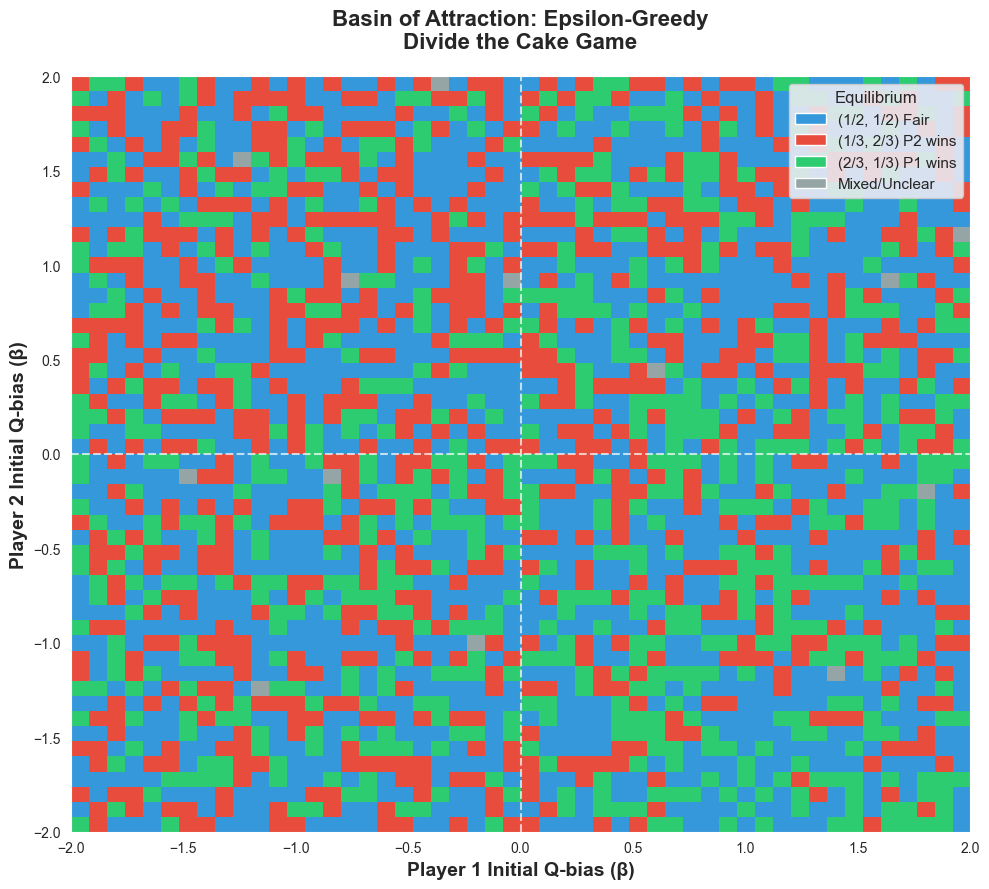


Epsilon-Greedy Basin Statistics:
(1/2, 1/2) Fair          : 1116/2500 ( 44.6%)
(1/3, 2/3) P2 wins       :  726/2500 ( 29.0%)
(2/3, 1/3) P1 wins       :  645/2500 ( 25.8%)
Mixed/Unclear            :   13/2500 (  0.5%)


In [22]:
# =============================================================================
# CELL 14: RUN BASIN CONSTRUCTION - EPSILON-GREEDY
# =============================================================================
# Construct basin of attraction map for Epsilon-Greedy policy.
#
# The bias parameter beta controls initial Q-value for the greedy action:
#   Q_0 = [0, 0, beta]
# Positive beta makes agent initially optimistic about demanding 2/3.
# Negative beta makes agent initially pessimistic about demanding 2/3.

print("\n" + "=" * 60)
print("CONSTRUCTING EPSILON-GREEDY BASIN MAP")
print("=" * 60)

basin_epsilon, params_epsilon = construct_basin_map(
    policy_type='epsilon_greedy',
    payoff_matrix_p1=game.payoff_matrix_p1,
    payoff_matrix_p2=game.payoff_matrix_p2,
    grid_resolution=GRID_RESOLUTION,
    n_episodes=N_EPISODES,
    n_timesteps=N_TIMESTEPS,
    param_range=PARAM_RANGES['epsilon_greedy'],
    policy_kwargs=POLICY_KWARGS['epsilon_greedy']
)

# Visualize
plot_basin_map(basin_epsilon, params_epsilon, 
               'Epsilon-Greedy', 'Initial Q-bias (β)',
               save_path='basin_epsilon_greedy.png')


CONSTRUCTING THOMPSON SAMPLING BASIN MAP
Constructing thompson basin map (50x50 grid)...
Parameter range: [-0.5, 0.5]
Total simulations: 2500
Episodes per simulation: 2000
Timesteps per episode: 5000
Total timesteps: 25,000,000,000

Submitted 2500 tasks to Ray workers...
Progress: 2500/2500 (100.0%) | Elapsed: 35092.1s | ETA: 0.0ssss

Completed in 35092.1 seconds (584.87 minutes)
Saved figure to: basin_thompson.png


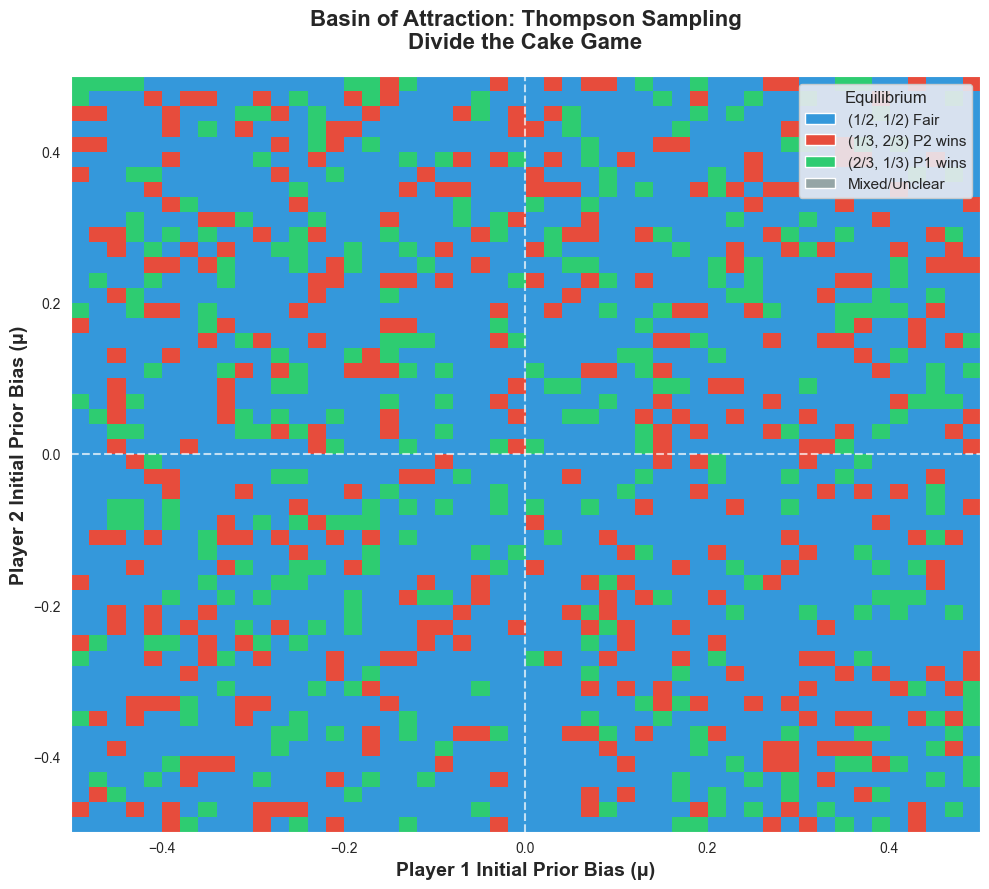


Thompson Sampling Basin Statistics:
(1/2, 1/2) Fair          : 1785/2500 ( 71.4%)
(1/3, 2/3) P2 wins       :  373/2500 ( 14.9%)
(2/3, 1/3) P1 wins       :  342/2500 ( 13.7%)
Mixed/Unclear            :    0/2500 (  0.0%)


In [23]:
# =============================================================================
# CELL 15: RUN BASIN CONSTRUCTION - THOMPSON SAMPLING
# =============================================================================
# Construct basin of attraction map for Thompson Sampling policy.
#
# The bias parameter mu controls initial prior mean for the greedy action:
#   posterior_mean_0 = [0, 0, mu]
# Positive mu makes agent initially optimistic about demanding 2/3.
# Negative mu makes agent initially pessimistic about demanding 2/3.

print("\n" + "=" * 60)
print("CONSTRUCTING THOMPSON SAMPLING BASIN MAP")
print("=" * 60)

basin_thompson, params_thompson = construct_basin_map(
    policy_type='thompson',
    payoff_matrix_p1=game.payoff_matrix_p1,
    payoff_matrix_p2=game.payoff_matrix_p2,
    grid_resolution=GRID_RESOLUTION,
    n_episodes=N_EPISODES,
    n_timesteps=N_TIMESTEPS,
    param_range=PARAM_RANGES['thompson'],
    policy_kwargs=POLICY_KWARGS['thompson']
)

# Visualize
plot_basin_map(basin_thompson, params_thompson,
               'Thompson Sampling', 'Initial Prior Bias (μ)',
               save_path='basin_thompson.png')


CONSTRUCTING EXP3 BASIN MAP
Constructing exp3 basin map (50x50 grid)...
Parameter range: [-0.3, 0.3]
Total simulations: 2500
Episodes per simulation: 2000
Timesteps per episode: 5000
Total timesteps: 25,000,000,000

Submitted 2500 tasks to Ray workers...
Progress: 2500/2500 (100.0%) | Elapsed: 140185.5s | ETA: 0.0ssss

Completed in 140185.5 seconds (2336.43 minutes)
Saved figure to: basin_exp3.png


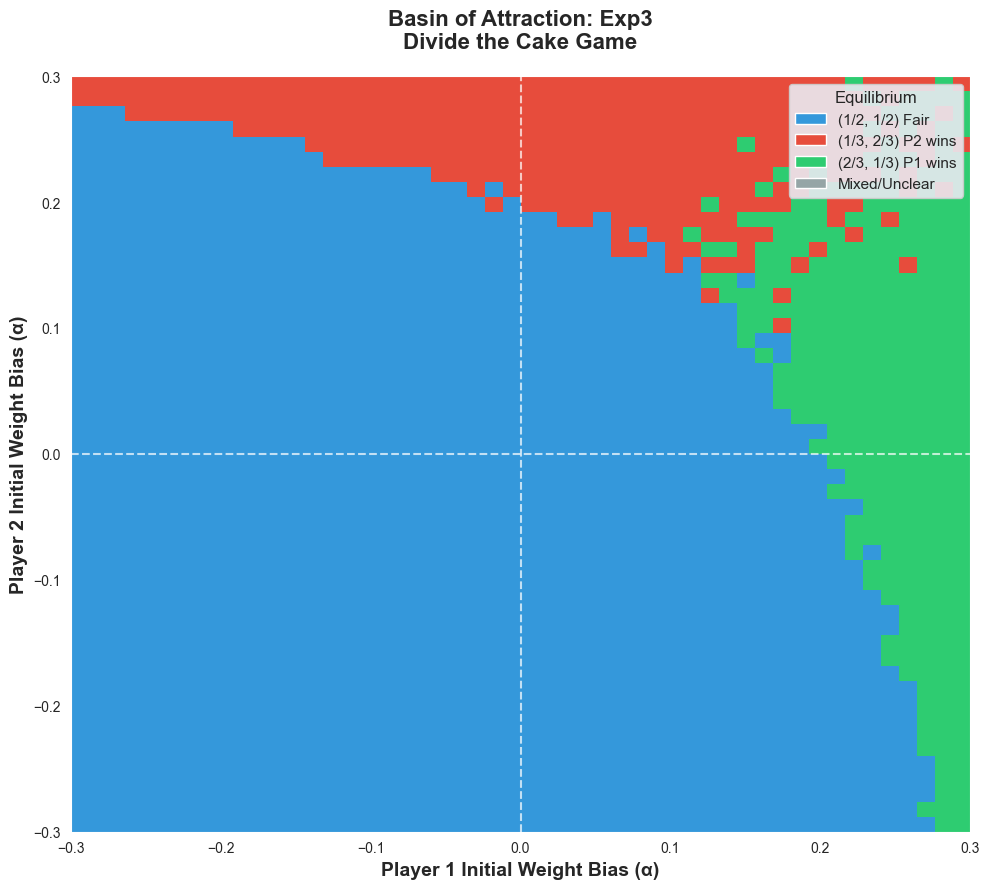


Exp3 Basin Statistics:
(1/2, 1/2) Fair          : 1829/2500 ( 73.2%)
(1/3, 2/3) P2 wins       :  332/2500 ( 13.3%)
(2/3, 1/3) P1 wins       :  339/2500 ( 13.6%)
Mixed/Unclear            :    0/2500 (  0.0%)


In [24]:
# =============================================================================
# CELL 16: RUN BASIN CONSTRUCTION - EXP3
# =============================================================================
# Construct basin of attraction map for Exp3 policy.
#
# The bias parameter alpha controls initial weight distribution:
#   w_0 = [0.1, 0.5 - alpha, 0.4 + alpha]
# Positive alpha shifts weight from fair action (1/2) to greedy action (2/3).
# Negative alpha shifts weight from greedy action to fair action.

print("\n" + "=" * 60)
print("CONSTRUCTING EXP3 BASIN MAP")
print("=" * 60)

basin_exp3, params_exp3 = construct_basin_map(
    policy_type='exp3',
    payoff_matrix_p1=game.payoff_matrix_p1,
    payoff_matrix_p2=game.payoff_matrix_p2,
    grid_resolution=GRID_RESOLUTION,
    n_episodes=N_EPISODES,
    n_timesteps=N_TIMESTEPS,
    param_range=PARAM_RANGES['exp3'],
    policy_kwargs=POLICY_KWARGS['exp3']
)

# Visualize
plot_basin_map(basin_exp3, params_exp3,
               'Exp3', 'Initial Weight Bias (α)',
               save_path='basin_exp3.png')


COMPARATIVE ANALYSIS
Saved comparison figure to: basin_comparison.png


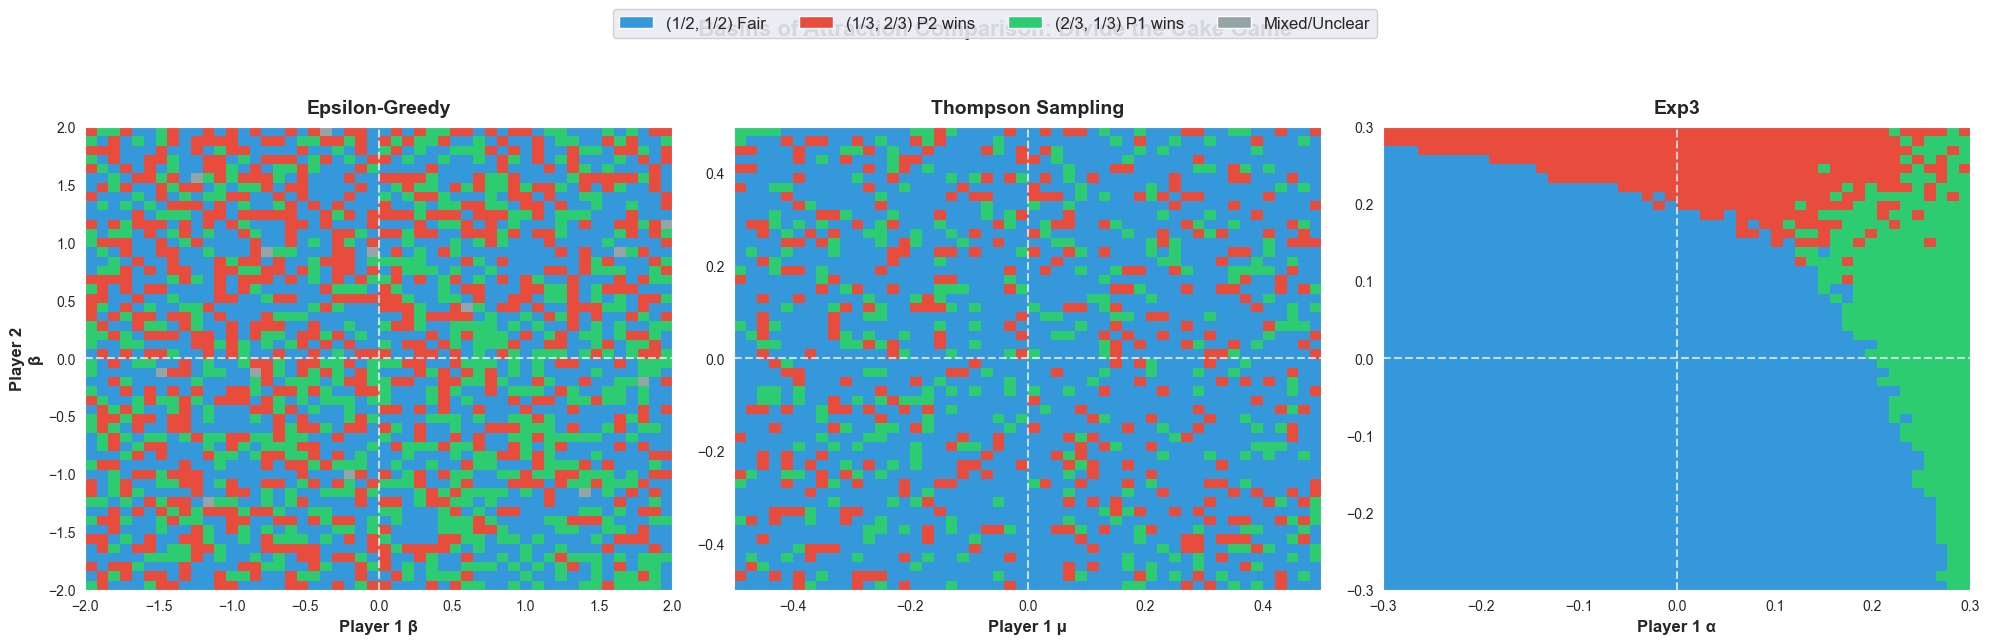


COMPARATIVE BASIN STATISTICS

Equilibrium               Epsilon-Greedy       Thompson           Exp3
--------------------------------------------------------------------------------
(1/2, 1/2) Fair                    44.6%          71.4%          73.2%
(1/3, 2/3) P2 wins                 29.0%          14.9%          13.3%
(2/3, 1/3) P1 wins                 25.8%          13.7%          13.6%
Mixed/Unclear                       0.5%           0.0%           0.0%

Key Observations:
--------------------------------------------------------------------------------
1. Exp3 has largest fair equilibrium basin (73.2%)

3. Symmetry Analysis:
   Epsilon-Greedy: P1 wins 25.8% vs P2 wins 29.0% (asymmetry: 3.2%)
   Thompson: P1 wins 13.7% vs P2 wins 14.9% (asymmetry: 1.2%)
   Exp3: P1 wins 13.6% vs P2 wins 13.3% (asymmetry: 0.3%)


In [25]:
# =============================================================================
# CELL 17: COMPARATIVE ANALYSIS
# =============================================================================
# Compare basin structures across all three policies.

print("\n" + "=" * 60)
print("COMPARATIVE ANALYSIS")
print("=" * 60)

# Side-by-side comparison plot
plot_basin_comparison(
    basin_maps=[basin_epsilon, basin_thompson, basin_exp3],
    param_values_list=[params_epsilon, params_thompson, params_exp3],
    policy_names=['Epsilon-Greedy', 'Thompson Sampling', 'Exp3'],
    param_names=['β', 'μ', 'α'],
    save_path='basin_comparison.png'
)

# Compute and display statistics
compute_basin_statistics(
    basin_maps=[basin_epsilon, basin_thompson, basin_exp3],
    policy_names=['Epsilon-Greedy', 'Thompson', 'Exp3']
)

In [26]:
# =============================================================================
# CELL 17A: SELECT STARTING POINTS FOR TRAJECTORY VISUALIZATION
# =============================================================================
# Choose interesting initial conditions from basin maps

# Starting point 1: Neutral (origin)
start_neutral = (0.0, 0.0)

# Starting point 2: Symmetric positive bias
start_positive = (0.5, 0.5) if RUN_MODE != 'ultra_fast' else (0.3, 0.3)

# Starting point 3: Asymmetric (P1 optimistic, P2 pessimistic)
start_asymmetric = (0.5, -0.5) if RUN_MODE != 'ultra_fast' else (0.3, -0.3)

starting_points = {
    'Neutral': start_neutral,
    'Symmetric Optimism': start_positive,
    'Asymmetric': start_asymmetric
}

print("Selected starting points:")
for name, (p1, p2) in starting_points.items():
    print(f"  {name}: P1 bias={p1:.2f}, P2 bias={p2:.2f}")

Selected starting points:
  Neutral: P1 bias=0.00, P2 bias=0.00
  Symmetric Optimism: P1 bias=0.50, P2 bias=0.50
  Asymmetric: P1 bias=0.50, P2 bias=-0.50


In [27]:
# =============================================================================
# CELL 17B: RUN TRAJECTORY SIMULATIONS
# =============================================================================
# Simulate trajectories from selected starting points

print("\n" + "=" * 60)
print("RUNNING TRAJECTORY SIMULATIONS")
print("=" * 60)

# Use smaller parameters for trajectory (don't need as many timesteps)
TRAJ_EPISODES = min(500, N_EPISODES)
TRAJ_TIMESTEPS = min(2000, N_TIMESTEPS)

trajectories = {}

for policy_type in ['epsilon_greedy', 'thompson', 'exp3']:
    print(f"\nSimulating {policy_type} trajectories...")
    trajectories[policy_type] = {}
    
    for start_name, (bias_p1, bias_p2) in starting_points.items():
        print(f"  From {start_name}... ", end='')
        
        # Get policy-specific parameters
        kwargs = POLICY_KWARGS[policy_type]
        param_range = PARAM_RANGES[policy_type]
        
        # Scale bias to policy's parameter range
        scale_p1 = bias_p1 * (param_range[1] - param_range[0]) / 2
        scale_p2 = bias_p2 * (param_range[1] - param_range[0]) / 2
        
        # Run simulation
        traj = simulate_trajectory(
            policy_type=policy_type,
            bias_p1=scale_p1,
            bias_p2=scale_p2,
            payoff_matrix_p1=game.payoff_matrix_p1,
            payoff_matrix_p2=game.payoff_matrix_p2,
            n_episodes=TRAJ_EPISODES,
            n_timesteps=TRAJ_TIMESTEPS,
            checkpoint_interval=100,
            policy_kwargs=kwargs
        )
        
        trajectories[policy_type][start_name] = traj
        print("Done")

print("\n" + "=" * 60)
print("TRAJECTORY SIMULATIONS COMPLETE")
print("=" * 60)


RUNNING TRAJECTORY SIMULATIONS

Simulating epsilon_greedy trajectories...
  From Neutral... Done
  From Symmetric Optimism... Done
  From Asymmetric... Done

Simulating thompson trajectories...
  From Neutral... Done
  From Symmetric Optimism... Done
  From Asymmetric... Done

Simulating exp3 trajectories...
  From Neutral... Done
  From Symmetric Optimism... Done
  From Asymmetric... Done

TRAJECTORY SIMULATIONS COMPLETE



GENERATING TRAJECTORY VISUALIZATIONS

Plotting Epsilon-Greedy trajectory from neutral start...
Saved trajectory figure to: trajectory_epsilon_greedy_neutral.png


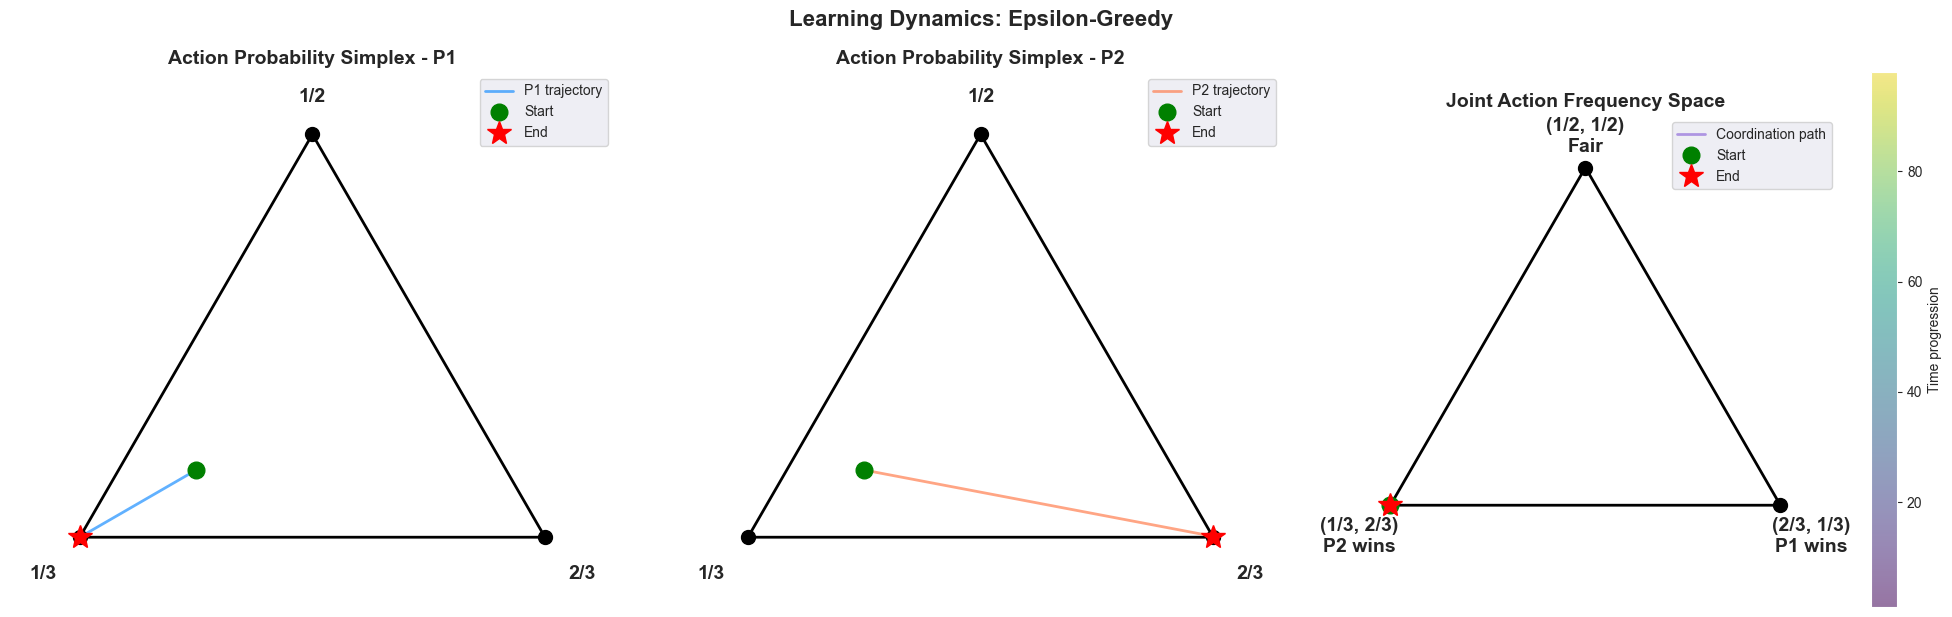


Plotting Thompson Sampling trajectory from neutral start...
Saved trajectory figure to: trajectory_thompson_neutral.png


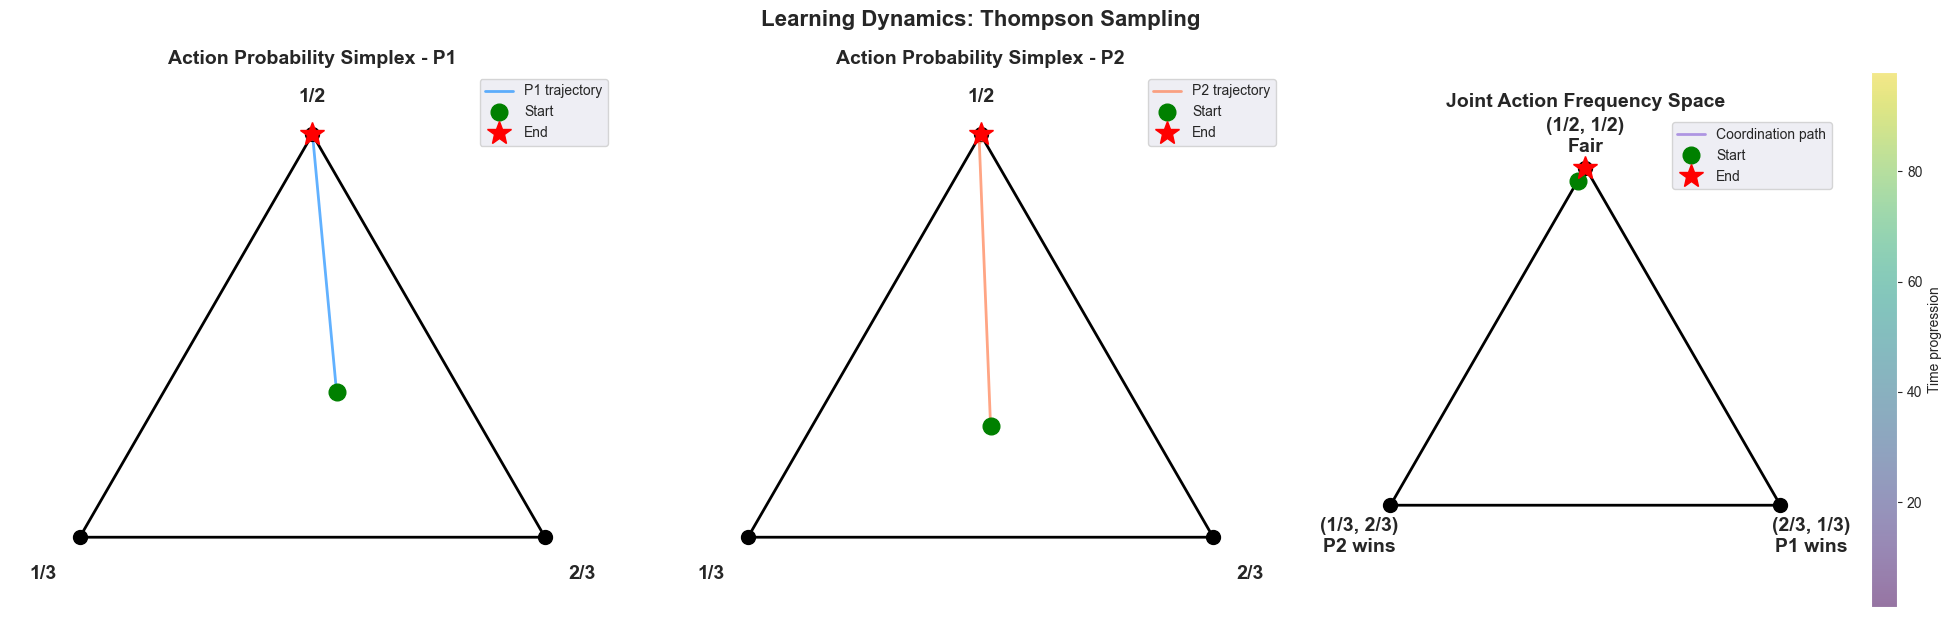


Plotting Exp3 trajectory from neutral start...
Saved trajectory figure to: trajectory_exp3_neutral.png


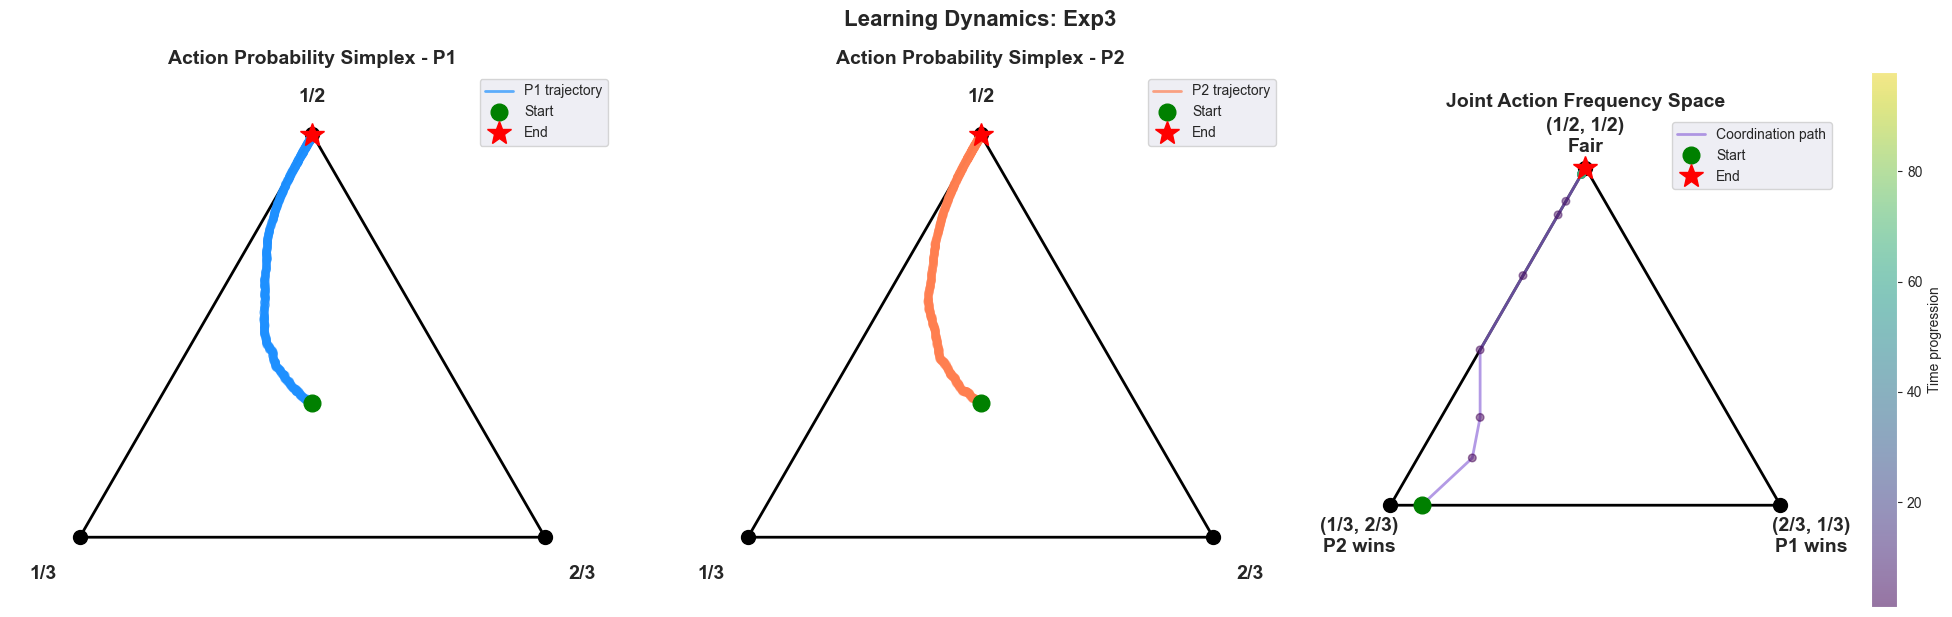


Individual trajectory plots complete


In [28]:
# =============================================================================
# CELL 17C: VISUALIZE INDIVIDUAL TRAJECTORIES
# =============================================================================
# Create trajectory plots for each policy from neutral starting point

print("\n" + "=" * 60)
print("GENERATING TRAJECTORY VISUALIZATIONS")
print("=" * 60)

for policy_type in ['epsilon_greedy', 'thompson', 'exp3']:
    policy_name = {
        'epsilon_greedy': 'Epsilon-Greedy',
        'thompson': 'Thompson Sampling',
        'exp3': 'Exp3'
    }[policy_type]
    
    print(f"\nPlotting {policy_name} trajectory from neutral start...")
    
    traj = trajectories[policy_type]['Neutral']
    
    plot_complete_trajectory(
        traj,
        policy_name=policy_name,
        save_path=f'trajectory_{policy_type}_neutral.png'
    )

print("\n" + "=" * 60)
print("Individual trajectory plots complete")
print("=" * 60)

Saved comparison figure to: trajectory_comparison_all_policies.png


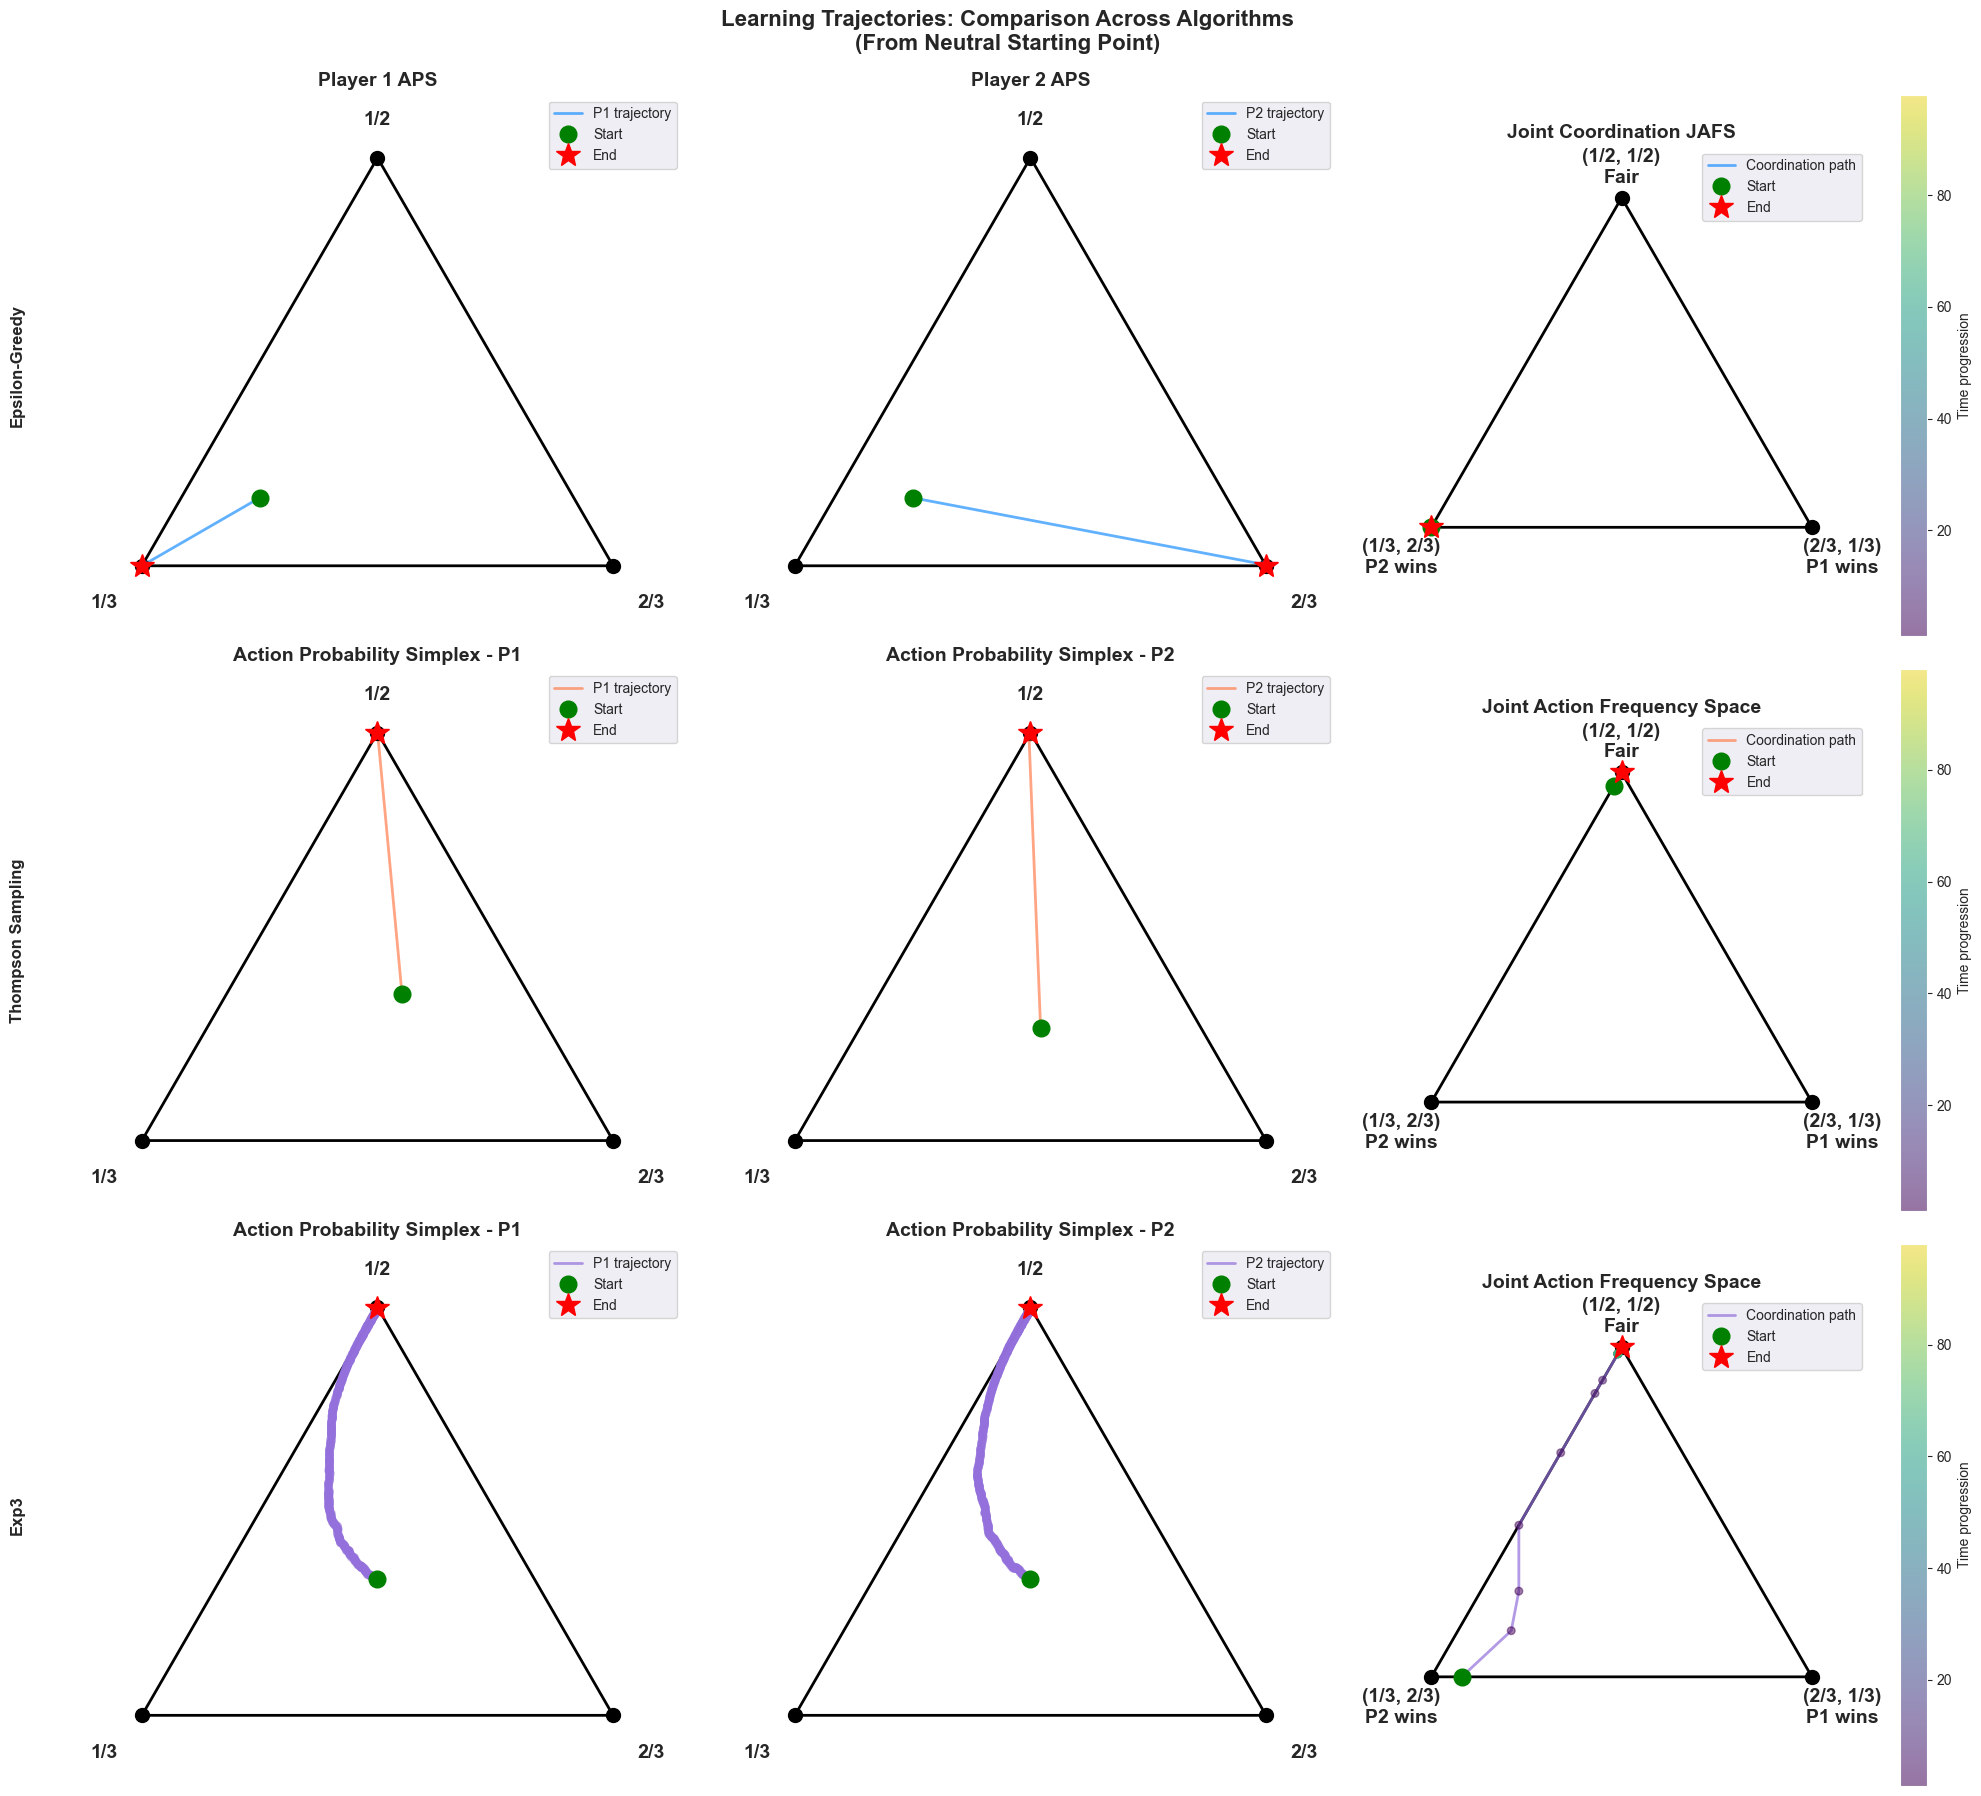


COMPARATIVE VISUALIZATION COMPLETE


In [29]:
# =============================================================================
# CELL 17D: COMPARATIVE TRAJECTORY VISUALIZATION
# =============================================================================
# Create side-by-side comparison of all three policies

fig, axes = plt.subplots(3, 3, figsize=(20, 18))

policy_types = ['epsilon_greedy', 'thompson', 'exp3']
policy_names = ['Epsilon-Greedy', 'Thompson Sampling', 'Exp3']
colors = ['dodgerblue', 'coral', 'mediumpurple']

for row, (policy_type, policy_name, color) in enumerate(zip(policy_types, policy_names, colors)):
    traj = trajectories[policy_type]['Neutral']
    
    # Column 1: P1 APS
    plot_aps_trajectory(traj, player='P1', ax=axes[row, 0], color=color)
    if row == 0:
        axes[row, 0].set_title('Player 1 APS', fontsize=14, fontweight='bold')
    axes[row, 0].text(-0.1, 0.5, policy_name, fontsize=12, fontweight='bold',
                     rotation=90, va='center', transform=axes[row, 0].transAxes)
    
    # Column 2: P2 APS
    plot_aps_trajectory(traj, player='P2', ax=axes[row, 1], color=color)
    if row == 0:
        axes[row, 1].set_title('Player 2 APS', fontsize=14, fontweight='bold')
    
    # Column 3: JAFS
    plot_jafs_trajectory(traj, ax=axes[row, 2], color=color)
    if row == 0:
        axes[row, 2].set_title('Joint Coordination JAFS', fontsize=14, fontweight='bold')

plt.suptitle('Learning Trajectories: Comparison Across Algorithms\n(From Neutral Starting Point)',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('trajectory_comparison_all_policies.png', dpi=300, bbox_inches='tight')
print("Saved comparison figure to: trajectory_comparison_all_policies.png")
plt.show()

print("\n" + "=" * 60)
print("COMPARATIVE VISUALIZATION COMPLETE")
print("=" * 60)

In [30]:
# =============================================================================
# CELL 18: SAVE RESULTS
# =============================================================================
# Save basin maps and parameters for later analysis.

import pickle
from datetime import datetime

print("\n" + "=" * 60)
print("SAVING RESULTS")
print("=" * 60)

# Collect all results
results = {
    'epsilon_greedy': {
        'basin_map': basin_epsilon,
        'param_values': params_epsilon,
        'param_range': PARAM_RANGES['epsilon_greedy'],
        'param_name': 'Initial Q-bias (β)'
    },
    'thompson': {
        'basin_map': basin_thompson,
        'param_values': params_thompson,
        'param_range': PARAM_RANGES['thompson'],
        'param_name': 'Initial Prior Bias (μ)'
    },
    'exp3': {
        'basin_map': basin_exp3,
        'param_values': params_exp3,
        'param_range': PARAM_RANGES['exp3'],
        'param_name': 'Initial Weight Bias (α)'
    },
    'experiment_params': {
        'run_mode': RUN_MODE,
        'grid_resolution': GRID_RESOLUTION,
        'n_episodes': N_EPISODES,
        'n_timesteps': N_TIMESTEPS,
        'game': 'divide_cake'
    },
    'timestamp': datetime.now().isoformat()
}

# Save to file
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"basin_results_{RUN_MODE}_{timestamp}.pkl"

with open(filename, 'wb') as f:
    pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Results saved to: {filename}")

# Also save as 'latest' for easy loading
with open('basin_results_latest.pkl', 'wb') as f:
    pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Results also saved to: basin_results_latest.pkl")
print("\n" + "=" * 60)


SAVING RESULTS
Results saved to: basin_results_full_20251201_081633.pkl
Results also saved to: basin_results_latest.pkl



In [31]:
# =============================================================================
# CELL 19: RAY SHUTDOWN
# =============================================================================
# Shutdown Ray to release resources.

print("Shutting down Ray...")
ray.shutdown()
print("Ray shutdown complete.")

print("\n" + "=" * 60)
print("BASIN CONSTRUCTION COMPLETE")
print("=" * 60)
print("\nAll basin maps have been constructed and saved.")
print("\nKey files:")
print("  - basin_epsilon_greedy.png")
print("  - basin_thompson.png")
print("  - basin_exp3.png")
print("  - basin_comparison.png")
print("  - basin_results_latest.pkl")

Shutting down Ray...
Ray shutdown complete.

BASIN CONSTRUCTION COMPLETE

All basin maps have been constructed and saved.

Key files:
  - basin_epsilon_greedy.png
  - basin_thompson.png
  - basin_exp3.png
  - basin_comparison.png
  - basin_results_latest.pkl


In [32]:
# =============================================================================
# CELL 20: DISCUSSION AND RESEARCH IMPLICATIONS
# =============================================================================
# Summary of research implications from basin construction analysis.
#
# LEARNING-BASED SELECTION MECHANISMS
# ------------------------------------
# The basins show that initial cognitive states + learning dynamics determine
# equilibrium selection:
#   - Not just rationality (RCT): Agents don't magically coordinate on fair equilibrium
#   - Not just evolution (EGT): We're tracking individual beliefs, not population frequencies
#   - Learning matters: Different initial beliefs lead to different outcomes
#
# MULTIPLE SELECTION MECHANISMS
# -----------------------------
# Each learning algorithm induces a different basin geometry. This shows MARL
# offers a family of selection mechanisms, not just one evolutionary dynamic.
#
# COGNITIVE STATE DYNAMICS
# ------------------------
# The state space is fundamentally different from EGT:
#   - EGT: Population frequency simplex (1-dimensional for 2-player symmetric)
#   - MARL: Product of individual state spaces (multidimensional)
#
# This enables:
#   - Richer basin structures
#   - Path-dependent convergence
#   - Role for initial beliefs/biases
#
# CONNECTION TO SOCIAL CONTRACT THEORY
# ------------------------------------
# For the Divide the Cake game as a running example:
#   - Large fair basin -> fairness is learnable and robust
#   - Algorithm differences -> no unique "natural" selection
#   - Sensitivity to initial conditions -> path dependence matters
#
# This provides empirical evidence for learning-based equilibrium selection
# that goes beyond what RCT or EGT can explain.
#
# =============================================================================

print("=" * 60)
print("RESEARCH SUMMARY")
print("=" * 60)
print("""
This notebook demonstrates how basins of attraction in MARL provide a
novel lens for understanding equilibrium selection in social contract theory.

Key findings:
1. Learning dynamics provide systematic selection mechanisms
2. Different algorithms induce qualitatively different basin structures
3. MARL operates in a richer state space than evolutionary dynamics

This supports positioning MARL as a "third tradition" that bridges the gap
between rational choice theory (which ignores learning) and evolutionary
game theory (which operates on population frequencies rather than individual
cognitive states).
""")
print("=" * 60)

RESEARCH SUMMARY

This notebook demonstrates how basins of attraction in MARL provide a
novel lens for understanding equilibrium selection in social contract theory.

Key findings:
1. Learning dynamics provide systematic selection mechanisms
2. Different algorithms induce qualitatively different basin structures
3. MARL operates in a richer state space than evolutionary dynamics

This supports positioning MARL as a "third tradition" that bridges the gap
between rational choice theory (which ignores learning) and evolutionary
game theory (which operates on population frequencies rather than individual
cognitive states).

